# 📊 Agent SDMX — interroger les données de la BAD en langage naturel
### ✅ Version 7 — 24 septembre 2026 · catalogue complet · mode JSON strict · tolérance aux modèles « raisonneurs »
### Atelier STG17 · BAD / STATAFRIC · Laboratoire avancé

> **En une phrase :** vous allez construire un agent qui **découvre** tout seul les jeux de données d’un service SDMX, **fabrique ses propres outils** à partir de ce qu’il découvre, **planifie** les appels nécessaires pour répondre à une question posée en français, puis **affiche** les résultats sous forme de tableau et de graphique — avec la trace complète des requêtes.

| ⏱ Durée | 🌍 Service cible | 🆓 Coût | 🔑 Clé d’API | 🧩 Dépendances |
|:--:|:--:|:--:|:--:|:--:|
| 2 h | SDMX REST (.Stat / NSI) | 0 € | facultative | `requests`, `pandas`, `matplotlib`, `ipywidgets` |

---

## 🎯 Les deux services visés

| Service | Rôle | URL |
|:--|:--|:--|
| **NSI Web Service** (BAD) | le **moteur SDMX** : structures et données | `https://datamanager.afdb.org/ws/nsi_ws/rest/` |
| **Data Browser** (BAD) | l’**interface web** qui consomme ce moteur | `https://dbrtest.opendataforafrica.org/#/en/afdb_test` |

Le Data Browser est une application web : elle ne s’interroge pas depuis Python. C’est donc le **NSI Web Service** qui est la cible de l’agent — exactement le même service que celui utilisé par le navigateur de données.

> ⚠️ **À vérifier au premier lancement.** La page d’accueil du service indique que l’instance peut n’être accessible **que depuis le réseau de la BAD** (« Is usable from external users: False »). Le notebook teste la connexion au démarrage et, si le service n’est pas joignable, bascule automatiquement sur :
> 1. un **service SDMX public de secours** (même technologie .Stat/NSI), pour que l’atelier fonctionne malgré tout ;
> 2. à défaut, un **instantané de démonstration** embarqué dans le notebook.
>
> Le mode retenu est affiché en clair, et l’agent indique toujours **d’où viennent ses chiffres**.

---

## 🗺️ Le parcours

| Partie | Étape | Contenu |
|:--|:--:|:--|
| **🟦 Comprendre** | 1 | Installation et configuration |
| | 2 | SDMX en 5 minutes : dataflow, DSD, dimensions, codelists, clé |
| **🟩 Se connecter** | 3 | Le client SDMX : requêtes, cache, erreurs, modes de repli |
| | 4 | Découverte automatique : quels jeux de données, quelles dimensions ? |
| **🟨 Outiller** | 5 | Les outils de l’agent, **générés à partir du service** |
| | 6 | Le protocole et la **planification** |
| | 7 | Politique, budget, journal d’audit |
| **🟪 Penser** | 8 | Les cerveaux : planificateur local ou modèle gratuit |
| | 9 | Essai en mode texte |
| **🟥 Utiliser** | 10 | **L’interface en langage naturel** |
| | 11 | Sous le capot |
| **⬛ Conclure** | 12 | Limites, exercices, dépannage |

---
# 🟦 PARTIE 1 — Comprendre

## Étape 1 · Installation et configuration

**🎯 Objectif :** un environnement identique pour tous, et une configuration centralisée du service visé.

Une seule variable compte : `ENDPOINTS`. Elle liste, dans l’ordre de préférence, les services SDMX à essayer. L’agent utilisera le premier qui répond.

In [1]:
# ── Étape 1 · Installation et configuration ─────────────────────────────────
import importlib, subprocess, sys

for module, paquet in [("requests", "requests"), ("pandas", "pandas>=2.0"),
                       ("matplotlib", "matplotlib>=3.7"), ("ipywidgets", "ipywidgets>=7.6")]:
    try:
        importlib.import_module(module)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", paquet], check=False)

import ast, base64, hashlib, html, io, json, operator, os, re, time, unicodedata, warnings
from dataclasses import dataclass, field
from datetime import datetime, timezone
from pathlib import Path
from typing import Callable, Optional

import matplotlib
matplotlib.use("Agg")                      # les figures sont rendues en images, pas affichées directement
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import HTML, display

# ── Services SDMX, par ordre de préférence ──────────────────────────────────
ENDPOINTS = [
    {"nom": "BAD · NSI Web Service", "url": "https://datamanager.afdb.org/ws/nsi_ws/rest",
     "agence": "all", "note": "cible de l’atelier ; peut être réservée au réseau interne de la BAD"},
    {"nom": ".Stat · service public de démonstration", "url": "https://nsi-demo-stable.siscc.org/rest",
     "agence": "all", "note": "même technologie (.Stat/NSI), accessible publiquement"},
    {"nom": "Pacific Data Hub · .Stat", "url": "https://stats-nsi-stable.pacificdata.org/rest",
     "agence": "SPC", "note": "autre instance .Stat publique, riche en dataflows"},
]
LANGUE = "fr"                 # langue demandée au service (en-tête Accept-Language)
DELAI = 25                    # secondes avant abandon d’une requête
MAX_OBSERVATIONS = 5000       # garde-fou : au-delà, la requête est refusée

RACINE = Path("stg17_sdmx")
CACHE = RACINE / "cache"
SORTIES = RACINE / "sorties"
for d in (CACHE, SORTIES):
    d.mkdir(parents=True, exist_ok=True)

# ── Charte graphique et fonctions d’affichage ───────────────────────────────
VERT, MARINE, OR, ROUGE, GRIS, CLAIR = "#1B7A43", "#0B2545", "#F2A900", "#B83B2E", "#6B7B75", "#EAF5EE"
POLICE = "font-family:Segoe UI,system-ui,-apple-system,sans-serif"
plt.rcParams.update({"figure.dpi": 120, "font.size": 10, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#9AA8A1", "axes.titleweight": "bold", "axes.titlesize": 12})

def _norm(texte):
    """Minuscules, sans accents : pour comparer des libellés indépendamment de la graphie."""
    texte = unicodedata.normalize("NFKD", str(texte).lower())
    return "".join(c for c in texte if not unicodedata.combining(c))


_STYLES = {"info": (VERT, "#EAF5EE", "💡"), "cle": (MARINE, "#E8EEF6", "🔑"), "attention": (OR, "#FFF7E0", "⚠️"),
           "danger": (ROUGE, "#FBECEA", "⛔"), "succes": (VERT, "#E3F4E9", "✅")}

def encadre(texte, titre="", genre="info"):
    couleur, fond, icone = _STYLES[genre]
    display(HTML(f"<div style='border-left:5px solid {couleur};background:{fond};padding:11px 16px;border-radius:8px;"
                 f"margin:8px 0;{POLICE};color:#1d2b24;line-height:1.5'><b>{icone} {titre}</b>"
                 f"<div style='margin-top:3px'>{texte}</div></div>"))

def df_vers_html(df, max_lignes=15):
    apercu = df.head(max_lignes)
    entetes = "".join(f"<th style='background:#0B2545;color:#fff;padding:5px 9px;text-align:left'>{html.escape(str(c))}</th>"
                      for c in apercu.columns)
    corps = ""
    for i, (_, ligne) in enumerate(apercu.iterrows()):
        fond = "#F4F7F5" if i % 2 else "#FFFFFF"
        corps += "<tr>" + "".join(f"<td style='padding:5px 9px;border-bottom:1px solid #DDE3E0;background:{fond}'>"
                                  f"{html.escape(str(v))}</td>" for v in ligne.values) + "</tr>"
    reste = (f"<div style='color:{GRIS};font-size:11.5px;margin-top:3px'>… {len(df) - max_lignes} ligne(s) de plus</div>"
             if len(df) > max_lignes else "")
    return (f"<div style='overflow-x:auto'><table style='border-collapse:collapse;font-size:12px;{POLICE};color:#1d2b24'>"
            f"<tr>{entetes}</tr>{corps}</table></div>{reste}")

def tableau(df, legende=None, max_lignes=15):
    bloc = df_vers_html(df, max_lignes)
    if legende:
        bloc += f"<div style='color:{GRIS};font-size:12px;font-style:italic;margin:2px 0 10px'>{legende}</div>"
    display(HTML(bloc))

def bandeau(surtitre, titre, sous_titre):
    display(HTML(f"<div style='background:linear-gradient(135deg,#0B2545 0%,#12507A 50%,#1B7A43 100%);border-radius:16px;"
                 f"padding:22px 30px;{POLICE};margin:6px 0'>"
                 f"<div style='color:#F2A900;font-size:12px;letter-spacing:3px;font-weight:700'>{surtitre}</div>"
                 f"<div style='color:#fff;font-size:26px;font-weight:800;margin:6px 0'>{titre}</div>"
                 f"<div style='color:#dbe7e0;font-size:14.5px;line-height:1.5'>{sous_titre}</div></div>"))

VERSION = "v7 · planification robuste"
bandeau(f"ATELIER STG17 · BAD / STATAFRIC · {VERSION}", "📊 Agent SDMX",
        "Une question en français → un plan → des requêtes SDMX → un tableau et un graphique, "
        "<b style='color:#fff'>avec la trace de chaque appel</b>.")
encadre(f"Dossier de travail : <code>{RACINE}/</code> · cache des requêtes : <code>{CACHE}/</code>",
        "Environnement prêt", "succes")

## Étape 2 · SDMX en 5 minutes

**🎯 Objectif :** comprendre les quatre notions sans lesquelles aucun agent ne peut interroger un service SDMX.

**SDMX** (*Statistical Data and Metadata eXchange*) est la norme ISO 17369 d’échange de données statistiques. Un service SDMX n’expose pas des « tableaux » : il expose des **cubes** décrits par leurs métadonnées.

| Notion | Ce que c’est | Exemple |
|:--|:--|:--|
| **Dataflow** | un jeu de données interrogeable | `DF_POP` — Population |
| **DSD** (*Data Structure Definition*) | la structure du cube : quelles dimensions, dans quel ordre | `FREQ · REF_AREA · INDICATOR · TIME_PERIOD` |
| **Dimension** | un axe du cube | `REF_AREA` (pays) |
| **Codelist** | la liste des valeurs autorisées d’une dimension | `CL_AREA` → `CIV` = Côte d’Ivoire |
| **Clé** (*key*) | la sélection dans le cube, dimensions séparées par `.` | `A.CIV.GDP_GROWTH` |

**L’URL d’une requête de données** suit toujours le même patron :

```
{service}/data/{agence},{dataflow},{version}/{clé}?startPeriod=2015&endPeriod=2023
```

Un point vide **élargit** la sélection, un `+` en **ajoute** une :

| Clé | Signification |
|:--|:--|
| `A.CIV.GDP_GROWTH` | annuel, Côte d’Ivoire, croissance du PIB |
| `A.CIV+SEN+GHA.GDP_GROWTH` | trois pays à la fois |
| `A..GDP_GROWTH` | tous les pays (2ᵉ dimension laissée vide) |
| `all` | tout le dataflow (⚠️ souvent volumineux) |

**🧠 Pourquoi c’est intéressant pour un agent.** Le service **se décrit lui-même** : l’agent peut demander la liste des dataflows, puis la structure de celui qui l’intéresse, puis les codes autorisés. Il n’a donc pas besoin qu’on lui code en dur la liste des pays ou des indicateurs : **il construit ses propres outils à partir des métadonnées**.

In [2]:
# ── Étape 2 · Schéma : du service à la réponse ──────────────────────────────
def _boite(x, y, w, h, titre, sous, bord, fond="#FFFFFF"):
    return (f"<rect x='{x}' y='{y}' width='{w}' height='{h}' rx='11' fill='{fond}' stroke='{bord}' stroke-width='2'/>"
            f"<text x='{x + w/2}' y='{y + h/2 - 3}' text-anchor='middle' font-size='13' font-weight='700' fill='#1d2b24'>{titre}</text>"
            f"<text x='{x + w/2}' y='{y + h/2 + 15}' text-anchor='middle' font-size='10.5' fill='#56655e'>{sous}</text>")

def _fleche(x1, y1, x2, y2, coul="#56655e", etiquette=""):
    return (f"<line x1='{x1}' y1='{y1}' x2='{x2}' y2='{y2}' stroke='{coul}' stroke-width='2' marker-end='url(#fl)'/>"
            + (f"<text x='{(x1+x2)/2}' y='{(y1+y2)/2 - 7}' text-anchor='middle' font-size='10.5' fill='{coul}'"
               f" font-weight='600'>{etiquette}</text>" if etiquette else ""))

display(HTML(f"""<svg viewBox='0 0 950 230' width='100%' style='max-width:950px;background:#fff;{POLICE}'>
<defs><marker id='fl' markerUnits='userSpaceOnUse' markerWidth='11' markerHeight='11' refX='10' refY='5.5' orient='auto'>
<path d='M0,0 L11,5.5 L0,11 z' fill='#56655e'/></marker></defs>
{_boite(10, 80, 150, 62, "❓ Question", "en français", MARINE, "#E8EEF6")}
{_boite(200, 80, 160, 62, "🗺️ Plan", "quels appels, dans quel ordre", OR, "#FFF7E0")}
{_boite(400, 20, 170, 62, "📚 /dataflow", "quels jeux de données ?", VERT, CLAIR)}
{_boite(400, 100, 170, 62, "🧱 /datastructure", "dimensions & codelists", VERT, CLAIR)}
{_boite(400, 175, 170, 45, "📈 /data", "les observations", VERT, CLAIR)}
{_boite(620, 80, 150, 62, "🧮 Traitement", "pandas : filtre, calcul", MARINE, "#E8EEF6")}
{_boite(800, 80, 140, 62, "📊 Réponse", "tableau + graphique", VERT, CLAIR)}
{_fleche(160, 111, 198, 111)}
{_fleche(360, 100, 398, 55, "#56655e", "1")}
{_fleche(360, 111, 398, 128, "#56655e", "2")}
{_fleche(360, 122, 398, 190, "#56655e", "3")}
{_fleche(572, 55, 618, 100)}
{_fleche(572, 131, 618, 115)}
{_fleche(572, 195, 618, 125)}
{_fleche(770, 111, 798, 111)}
</svg>"""))
encadre("L’agent ne devine jamais un code pays ou un indicateur : il interroge d’abord les <b>métadonnées</b> "
        "(étapes 1 et 2), puis construit la clé de la requête de données (étape 3).", "Le principe", "cle")

---
# 🟩 PARTIE 2 — Se connecter

## Étape 3 · Le client SDMX

**🎯 Objectif :** une couche réseau **robuste**, car un agent qui interroge un service distant doit survivre aux lenteurs, aux formats inattendus et aux indisponibilités.

Le client fait six choses qu’un simple `requests.get` ne fait pas :

1. **Négocie le format** : il demande du SDMX-JSON et retombe sur `?format=sdmx-json` si le service refuse l’en-tête `Accept` ;
2. **Met en cache** chaque réponse sur le disque : une même requête n’est jamais payée deux fois (et l’atelier reste rapide) ;
3. **Limite le débit** pour ne pas saturer le service ;
4. **Traduit les erreurs HTTP** en messages lisibles par l’agent (404 = dataflow inconnu, 413 = requête trop volumineuse…) ;
5. **Comprend les deux versions** de SDMX-JSON (1.0 et 2.0), dont les structures diffèrent ;
6. **Bascule** automatiquement d’un service à l’autre, puis vers l’instantané de démonstration.

In [3]:
# ── Étape 3 · Client SDMX REST ──────────────────────────────────────────────
ACCEPT_STRUCTURE = "application/vnd.sdmx.structure+json;version=1.0.0"
ACCEPT_DONNEES = "application/vnd.sdmx.data+json;version=1.0.0"


class ErreurSDMX(Exception):
    """Erreur renvoyée par le service, traduite en message lisible."""


class ClientSDMX:
    """Client SDMX REST 1.5 : structures et données, avec cache disque et repli."""

    def __init__(self, base_url, langue=LANGUE, delai=DELAI, cache=CACHE, intervalle=0.4):
        self.base = base_url.rstrip("/")
        self.langue, self.delai, self.cache, self.intervalle = langue, delai, Path(cache), intervalle
        self.cache.mkdir(parents=True, exist_ok=True)
        self.requetes, self.depuis_cache, self._dernier = 0, 0, 0.0
        self.journal_http = []

    # ── couche réseau ──────────────────────────────────────────────────────
    def _fichier_cache(self, url):
        return self.cache / (hashlib.sha256(url.encode()).hexdigest()[:24] + ".json")

    def get(self, chemin, params=None, accept=ACCEPT_STRUCTURE, utiliser_cache=True):
        url = f"{self.base}/{chemin.lstrip('/')}"
        if params:
            url += "?" + "&".join(f"{k}={v}" for k, v in params.items() if v not in (None, ""))
        fichier = self._fichier_cache(url)
        if utiliser_cache and fichier.exists():
            self.depuis_cache += 1
            self.journal_http.append({"url": url, "statut": "cache", "ms": 0})
            return json.loads(fichier.read_text(encoding="utf-8"))

        attente = self.intervalle - (time.monotonic() - self._dernier)
        if attente > 0:
            time.sleep(attente)
        self._dernier = time.monotonic()
        t0 = time.perf_counter()
        self.requetes += 1
        entetes = {"Accept": accept, "Accept-Language": self.langue}
        try:
            r = requests.get(url, headers=entetes, timeout=self.delai)
            if r.status_code == 406:                        # format refusé : on réessaie autrement
                separateur = "&" if "?" in url else "?"
                r = requests.get(url + separateur + "format=sdmx-json", timeout=self.delai,
                                 headers={"Accept-Language": self.langue})
        except requests.RequestException as e:
            self.journal_http.append({"url": url, "statut": f"réseau: {type(e).__name__}", "ms": 0})
            raise ErreurSDMX(f"service injoignable ({type(e).__name__})") from e
        duree = (time.perf_counter() - t0) * 1000
        self.journal_http.append({"url": url, "statut": r.status_code, "ms": round(duree)})

        if r.status_code == 404:
            raise ErreurSDMX("introuvable (404) : vérifiez l’identifiant du dataflow, l’agence ou la clé")
        if r.status_code == 413:
            raise ErreurSDMX("requête trop volumineuse (413) : restreignez la clé ou la période")
        if r.status_code == 400:
            raise ErreurSDMX(f"requête invalide (400) : {r.text[:150]}")
        if not r.ok:
            raise ErreurSDMX(f"erreur HTTP {r.status_code}")
        if not r.text.strip():
            raise ErreurSDMX("réponse vide (aucune donnée pour cette sélection)")
        try:
            donnees = r.json()
        except ValueError as e:
            raise ErreurSDMX("réponse illisible (le service n’a pas renvoyé du JSON)") from e
        if utiliser_cache:
            fichier.write_text(json.dumps(donnees, ensure_ascii=False), encoding="utf-8")
        return donnees

    # ── lecture tolérante des deux versions de SDMX-JSON ───────────────────
    @staticmethod
    def _racine(charge):
        return charge.get("data", charge)

    @staticmethod
    def _nom(objet, langue=LANGUE):
        noms = objet.get("names") or {}
        nom = noms.get(langue) or objet.get("name") or noms.get("en")
        if isinstance(nom, dict):
            nom = nom.get(langue) or nom.get("en") or next(iter(nom.values()), "")
        return nom or objet.get("id", "")

    # ── structures ─────────────────────────────────────────────────────────
    def dataflux(self, agence="all", limite=None):
        """Liste des dataflows : identifiant, agence, version, nom."""
        charge = self.get(f"dataflow/{agence}/all/latest", {"detail": "allstubs"})
        lignes = [{"agence": f.get("agencyID", ""), "flux": f.get("id", ""), "version": f.get("version", "1.0"),
                   "nom": self._nom(f)} for f in self._racine(charge).get("dataflows", [])]
        table = pd.DataFrame(lignes).sort_values("flux").reset_index(drop=True)
        return table.head(limite) if limite else table

    def structure(self, agence, flux, version="latest"):
        """Dimensions d’un dataflow et codes autorisés (codelists partielles)."""
        charge = self.get(f"dataflow/{agence}/{flux}/{version}",
                          {"references": "all", "detail": "referencepartial"})
        racine = self._racine(charge)
        codelists = {}
        for cl in racine.get("codelists", []):
            urn = f"{cl.get('agencyID')}:{cl.get('id')}({cl.get('version', '1.0')})"
            codelists[urn] = [{"code": c.get("id"), "libelle": self._nom(c)} for c in cl.get("codes", [])]
        dsd = (racine.get("dataStructures") or [{}])[0]
        composants = dsd.get("dataStructureComponents", {})
        dimensions = []
        for dim in composants.get("dimensionList", {}).get("dimensions", []):
            enumeration = ((dim.get("localRepresentation") or {}).get("enumeration") or "")
            cle_cl = enumeration.split("=")[-1] if "=" in enumeration else ""
            dimensions.append({"id": dim.get("id"), "position": dim.get("position", len(dimensions) + 1),
                               "nom": self._nom(dim) if dim.get("name") else dim.get("id"),
                               "codes": codelists.get(cle_cl, [])})
        dimensions.sort(key=lambda d: d["position"])
        temps = composants.get("dimensionList", {}).get("timeDimensions", [])
        flux_nom = next((self._nom(f) for f in racine.get("dataflows", []) if f.get("id") == flux), flux)
        return {"agence": agence, "flux": flux, "version": version, "nom": flux_nom,
                "dimensions": dimensions, "dimension_temps": (temps[0].get("id") if temps else "TIME_PERIOD"),
                "dsd": dsd.get("id", "")}

    # ── données ────────────────────────────────────────────────────────────
    def donnees(self, agence, flux, cle="all", version="latest", debut=None, fin=None, dernieres=None):
        params = {"startPeriod": debut, "endPeriod": fin, "lastNObservations": dernieres,
                  "dimensionAtObservation": "AllDimensions"}
        charge = self.get(f"data/{agence},{flux},{version}/{cle or 'all'}", params, accept=ACCEPT_DONNEES)
        return self.vers_dataframe(charge)

    @classmethod
    def vers_dataframe(cls, charge):
        """Convertit un message SDMX-JSON (1.0 ou 2.0) en tableau plat."""
        racine = cls._racine(charge)
        jeux = racine.get("dataSets") or []
        structures = racine.get("structures") or ([racine["structure"]] if "structure" in racine else [])
        if not jeux or not structures:
            return pd.DataFrame()
        structure = structures[0]
        dims_obs = (structure.get("dimensions", {}).get("observation") or [])
        dims_series = (structure.get("dimensions", {}).get("series") or [])
        lignes = []
        for jeu in jeux:
            # cas 1 : vue plate (AllDimensions)
            for cle, valeurs in (jeu.get("observations") or {}).items():
                indices = [int(i) for i in cle.split(":")]
                ligne = {d["id"]: d["values"][i]["id"] for d, i in zip(dims_obs, indices)}
                ligne["OBS_VALUE"] = valeurs[0] if valeurs else None
                lignes.append(ligne)
            # cas 2 : vue série + observations
            for cle_serie, serie in (jeu.get("series") or {}).items():
                indices = [int(i) for i in cle_serie.split(":")]
                base = {d["id"]: d["values"][i]["id"] for d, i in zip(dims_series, indices)}
                for cle_obs, valeurs in (serie.get("observations") or {}).items():
                    ligne = dict(base)
                    for d, i in zip(dims_obs, [int(x) for x in cle_obs.split(":")]):
                        ligne[d["id"]] = d["values"][i]["id"]
                    ligne["OBS_VALUE"] = valeurs[0] if valeurs else None
                    lignes.append(ligne)
        table = pd.DataFrame(lignes)
        if not table.empty:
            table["OBS_VALUE"] = pd.to_numeric(table["OBS_VALUE"], errors="coerce")
            # libellés lisibles pour chaque dimension
            for dim in list(dims_obs) + list(dims_series):
                libelles = {v["id"]: cls._nom(v) for v in dim.get("values", [])}
                if dim["id"] in table.columns and libelles:
                    table[dim["id"] + "_LIBELLE"] = table[dim["id"]].map(libelles)
            colonnes_temps = [c for c in table.columns if c.startswith("TIME")]
            if colonnes_temps:
                table = table.sort_values(colonnes_temps[0]).reset_index(drop=True)
        return table

In [4]:
# ── Étape 3 (suite) · Instantané de démonstration multi-dataflows ───────────
# Données FICTIVES, au format SDMX-JSON, pour que le notebook fonctionne même sans réseau.
_PAYS = [("CIV", "Côte d’Ivoire"), ("SEN", "Sénégal"), ("GHA", "Ghana"), ("NGA", "Nigéria"),
         ("TUN", "Tunisie"), ("MAR", "Maroc"), ("KEN", "Kenya")]
_ANNEES = [str(a) for a in range(2015, 2024)]

DEMO_FLUX = {
    "DF_MACRO_DEMO": {"nom": "Indicateurs macroéconomiques (démonstration)",
                      "indicateurs": [("GDP_GROWTH", "Croissance du PIB réel", 5.0), ("INFLATION", "Inflation, prix à la consommation", 3.0),
                                      ("UNEMP", "Taux de chômage", 9.0), ("GDP_CAPITA", "PIB par habitant, USD courants", 2400.0)]},
    "DF_POP_DEMO": {"nom": "Population et démographie (démonstration)",
                    "indicateurs": [("POP_TOT", "Population totale, millions", 28.0), ("URBAN_PCT", "Population urbaine, % du total", 48.0),
                                    ("POP_GROWTH", "Croissance démographique annuelle", 2.6)]},
    "DF_EDU_DEMO": {"nom": "Éducation (démonstration)",
                    "indicateurs": [("LITERACY", "Taux d’alphabétisation des adultes", 62.0),
                                    ("COMPLETION_PRIM", "Taux d’achèvement du primaire", 78.0),
                                    ("PUPIL_TEACHER", "Ratio élèves / enseignant", 38.0)]},
    "DF_TRADE_DEMO": {"nom": "Commerce extérieur et matières premières (démonstration)",
                      "indicateurs": [("EXPORTS_GOODS", "Exportations de biens, % du PIB", 24.0),
                                      ("IMPORTS_GOODS", "Importations de biens, % du PIB", 26.0),
                                      ("COCOA_PROD", "Production de cacao, milliers de tonnes", 900.0)]},
    "DF_SANTE_DEMO": {"nom": "Santé (démonstration)",
                      "indicateurs": [("LIFE_EXP", "Espérance de vie à la naissance", 62.0),
                                      ("VACC_DTP3", "Couverture vaccinale DTC3", 82.0)]},
}

def _valeur_demo(flux, pays, indicateur, annee, base):
    """Série fictive mais déterministe : sert uniquement à faire fonctionner la démonstration."""
    decalage = (sum(ord(c) for c in pays + indicateur) % 9) - 4
    choc = -0.25 * base if (annee == "2020" and indicateur in ("GDP_GROWTH", "EXPORTS_GOODS")) else 0.0
    tendance = (int(annee) - 2015) * (base * 0.012 if indicateur not in ("UNEMP", "PUPIL_TEACHER") else -base * 0.008)
    return round(base * (1 + decalage * 0.02) + tendance + choc, 1)

def _structure_demo(flux):
    conf = DEMO_FLUX[flux]
    return {"data": {
        "dataflows": [{"id": flux, "agencyID": "DEMO", "version": "1.0", "name": conf["nom"]}],
        "dataStructures": [{"id": f"DSD_{flux}", "dataStructureComponents": {"dimensionList": {
            "dimensions": [
                {"id": "FREQ", "position": 1, "localRepresentation": {"enumeration": "urn:…Codelist=DEMO:CL_FREQ(1.0)"}},
                {"id": "REF_AREA", "position": 2, "localRepresentation": {"enumeration": "urn:…Codelist=DEMO:CL_AREA(1.0)"}},
                {"id": "INDICATOR", "position": 3, "localRepresentation": {"enumeration": f"urn:…Codelist=DEMO:CL_IND_{flux}(1.0)"}}],
            "timeDimensions": [{"id": "TIME_PERIOD"}]}}}],
        "codelists": [
            {"id": "CL_FREQ", "agencyID": "DEMO", "version": "1.0", "codes": [{"id": "A", "name": "Annuelle"}]},
            {"id": "CL_AREA", "agencyID": "DEMO", "version": "1.0", "codes": [{"id": c, "name": n} for c, n in _PAYS]},
            {"id": f"CL_IND_{flux}", "agencyID": "DEMO", "version": "1.0",
             "codes": [{"id": c, "name": n} for c, n, _ in conf["indicateurs"]]}]}}

def _donnees_demo(flux):
    conf = DEMO_FLUX[flux]
    observations = {}
    for i, (pays, _) in enumerate(_PAYS):
        for j, (code, _, base) in enumerate(conf["indicateurs"]):
            for k, annee in enumerate(_ANNEES):
                observations[f"0:{i}:{j}:{k}"] = [_valeur_demo(flux, pays, code, annee, base)]
    return {"data": {"dataSets": [{"observations": observations}], "structure": {"dimensions": {"observation": [
        {"id": "FREQ", "values": [{"id": "A", "name": "Annuelle"}]},
        {"id": "REF_AREA", "values": [{"id": c, "name": n} for c, n in _PAYS]},
        {"id": "INDICATOR", "values": [{"id": c, "name": n} for c, n, _ in conf["indicateurs"]]},
        {"id": "TIME_PERIOD", "values": [{"id": a, "name": a} for a in _ANNEES]}]}}}}

SNAPSHOT_FLUX = {"data": {"dataflows": [{"id": f, "agencyID": "DEMO", "version": "1.0", "name": c["nom"]}
                                        for f, c in DEMO_FLUX.items()]}}


class ClientDemo(ClientSDMX):
    """Client hors ligne : rejoue un instantané de 5 dataflows. Les chiffres sont FICTIFS."""

    def __init__(self):
        super().__init__("https://demo.local/rest")
        self.demo = True

    def get(self, chemin, params=None, accept=None, utiliser_cache=True):
        self.requetes += 1
        self.journal_http.append({"url": f"[démo] {chemin}", "statut": "démo", "ms": 0})
        if chemin.startswith("dataflow") and "all/latest" not in chemin:
            flux = chemin.split("/")[2]
            if flux not in DEMO_FLUX:
                raise ErreurSDMX(f"dataflow inconnu dans l’instantané : {flux}")
            return _structure_demo(flux)
        if chemin.startswith("dataflow"):
            return SNAPSHOT_FLUX
        if chemin.startswith("data/"):
            reference, _, cle = chemin[len("data/"):].partition("/")
            flux = reference.split(",")[1] if "," in reference else reference
            table = self.vers_dataframe(_donnees_demo(flux))
            cle = cle.split("?")[0]
            if cle and cle != "all":
                for position, selection in enumerate(cle.split(".")):
                    if not selection:
                        continue
                    colonne = ["FREQ", "REF_AREA", "INDICATOR"][position]
                    table = table[table[colonne].isin(selection.split("+"))]
            debut, fin = (params or {}).get("startPeriod"), (params or {}).get("endPeriod")
            if debut:
                table = table[table["TIME_PERIOD"] >= str(debut)]
            if fin:
                table = table[table["TIME_PERIOD"] <= str(fin)]
            return {"__dataframe__": table.reset_index(drop=True)}
        raise ErreurSDMX(f"ressource non simulée : {chemin}")

    def donnees(self, agence, flux, cle="all", version="latest", debut=None, fin=None, dernieres=None):
        charge = self.get(f"data/{agence},{flux},{version}/{cle or 'all'}",
                          {"startPeriod": debut, "endPeriod": fin})
        table = charge["__dataframe__"]
        if dernieres:
            groupes = [c for c in ("FREQ", "REF_AREA", "INDICATOR") if c in table.columns]
            table = table.sort_values("TIME_PERIOD").groupby(groupes, as_index=False).tail(int(dernieres))
        return table.reset_index(drop=True)


def connecter(endpoints=ENDPOINTS, forcer_demo=False):
    """Essaie chaque service dans l’ordre ; bascule sur l’instantané en dernier recours."""
    if forcer_demo:
        return ClientDemo(), {"nom": "Instantané de démonstration", "url": "—", "agence": "DEMO",
                              "note": "aucune connexion réseau ; chiffres fictifs"}
    for point in endpoints:
        client = ClientSDMX(point["url"])
        try:
            flux = client.dataflux(point.get("agence", "all"), limite=1)
            if not flux.empty:
                return client, point
        except Exception as e:
            print(f"   ⚠️ {point['nom']} : {e}")
    print("   ⚠️ aucun service joignable : bascule sur l’instantané de démonstration")
    return ClientDemo(), {"nom": "Instantané de démonstration", "url": "—", "agence": "DEMO",
                          "note": "aucun service joignable ; chiffres fictifs"}


print("Connexion aux services SDMX…")
CLIENT, SERVICE = connecter()
MODE_DEMO = isinstance(CLIENT, ClientDemo)
encadre(f"Service utilisé : <b>{SERVICE['nom']}</b><br><code>{SERVICE['url']}</code><br><i>{SERVICE['note']}</i>",
        "Connexion établie", "attention" if MODE_DEMO else "succes")
if MODE_DEMO:
    encadre("Le notebook fonctionne avec des <b>données fictives</b> (5 dataflows) : la mécanique de l’agent est réelle, "
            "les chiffres ne le sont pas. Relancez depuis le réseau de la BAD pour interroger le service NSI.",
            "Mode démonstration", "attention")

Connexion aux services SDMX…
   ⚠️ BAD · NSI Web Service : erreur HTTP 403
   ⚠️ .Stat · service public de démonstration : erreur HTTP 403
   ⚠️ Pacific Data Hub · .Stat : erreur HTTP 403
   ⚠️ aucun service joignable : bascule sur l’instantané de démonstration


## Étape 4 · Découvrir **tout** le catalogue

**🎯 Objectif :** ne pas se limiter à un jeu de données. L’agent doit pouvoir atteindre **l’ensemble des données publiées** par le service.

Trois niveaux de découverte, du moins cher au plus cher :

| Niveau | Appel | Coût | Ce qu’on obtient |
|:--|:--|:--:|:--|
| **① Catalogue** | `GET /dataflow/{agence}/all/latest?detail=allstubs` | 1 requête | tous les jeux de données et leurs libellés |
| **② Structures** | `GET /dataflow/{agence}/{flux}/latest?references=all&detail=referencepartial` | 1 requête **par dataflow** | dimensions et codes réellement utilisés |
| **③ Données** | `GET /data/{agence},{flux},{version}/{clé}` | 1 requête par extraction | les observations |

Le niveau ② est le plus coûteux : sur un service qui publie 200 dataflows, l’indexation complète représente 200 requêtes. Le notebook l’assume avec trois précautions : un **cache disque** (une structure n’est lue qu’une fois), un **plafond** réglable (`MAX_FLUX_INDEXES`), et une **indexation paresseuse** — un dataflow non indexé le sera au moment où l’agent en aura besoin.

**🧠 Ce que l’indexation permet.** Elle construit un annuaire `libellé → (dataflow, dimension, code)`. L’agent peut alors répondre à « quel jeu de données contient l’alphabétisation ? » sans deviner, et surtout **choisir lui-même le bon dataflow** avant de construire sa clé.

In [5]:
# ── Étape 4 · Le catalogue et son index ─────────────────────────────────────
MAX_FLUX_INDEXES = 12        # plafond d’indexation au démarrage (augmentez si le service est petit)
INDEXER_TOUT = False         # True = indexer tous les dataflows, quel qu’en soit le nombre


def normaliser_flux(valeur):
    """Accepte « DF_POP », « DEMO,DF_POP,1.0 », « DEMO:DF_POP(1.0) » ou une URN → renvoie (agence, flux)."""
    texte = str(valeur or "").strip()
    if not texte:
        return None, None
    if texte.startswith("urn:"):
        texte = texte.split("=")[-1]
    texte = texte.replace("(", ",").replace(")", "").replace(":", ",")
    morceaux = [m for m in texte.split(",") if m]
    if len(morceaux) == 1:
        return None, morceaux[0]
    agence, flux = morceaux[0], morceaux[1]
    return agence, flux


class CatalogueSDMX:
    """Catalogue complet du service : dataflows, structures (en cache) et index des codes."""

    def __init__(self, client, agence="all"):
        self.client, self.agence = client, agence
        self.flux = client.dataflux(agence)
        self._structures, self._echecs = {}, {}
        self.index = pd.DataFrame(columns=["flux", "flux_nom", "dimension", "code", "libelle", "libelle_norm"])

    # ── structures, avec cache mémoire + cache disque du client ────────────
    def structure(self, flux, agence=None):
        agence_extraite, flux = normaliser_flux(flux)      # tolère « AGENCE,FLUX,VERSION »
        agence = agence or agence_extraite
        if flux in self._structures:
            return self._structures[flux]
        if flux in self._echecs:
            raise ErreurSDMX(self._echecs[flux])
        ligne = self.flux[self.flux["flux"] == flux]
        agence = agence or (ligne.iloc[0]["agence"] if not ligne.empty else self.agence)
        try:
            structure = self.client.structure(agence, flux)
        except Exception as e:
            self._echecs[flux] = str(e)
            raise
        self._structures[flux] = structure
        return structure

    # ── indexation ─────────────────────────────────────────────────────────
    def indexer(self, flux_a_indexer=None, bavard=True):
        cibles = flux_a_indexer or list(self.flux["flux"])
        if not INDEXER_TOUT and flux_a_indexer is None:
            cibles = cibles[:MAX_FLUX_INDEXES]
        lignes, indexes = [], 0
        for flux in cibles:
            if flux in self._structures or flux in self._echecs:
                continue
            try:
                structure = self.structure(flux)
            except Exception:
                continue
            indexes += 1
            for dim in structure["dimensions"]:
                for c in dim["codes"]:
                    lignes.append({"flux": flux, "flux_nom": structure["nom"], "dimension": dim["id"],
                                   "code": c["code"], "libelle": c["libelle"], "libelle_norm": _norm(c["libelle"])})
        if lignes:
            self.index = pd.concat([self.index, pd.DataFrame(lignes)], ignore_index=True).drop_duplicates()
        if bavard:
            print(f"   {indexes} dataflow(s) indexé(s) · {len(self.index)} code(s) au total"
                  + (f" · {len(self._echecs)} en échec" if self._echecs else ""))
        return self.index

    # ── recherche ──────────────────────────────────────────────────────────
    @staticmethod
    def _mots(texte):
        vides = {"de", "du", "des", "la", "le", "les", "un", "une", "et", "en", "au", "aux", "pour", "par", "sur",
                 "quel", "quelle", "combien", "dans", "taux", "annee", "depuis", "entre"}
        return {m for m in re.findall(r"[a-z0-9]+", _norm(texte)) if len(m) > 2 and m not in vides}

    def chercher_flux(self, texte, k=5):
        """Classe les dataflows par pertinence : libellé du flux + libellés de ses codes indexés."""
        mots = self._mots(texte)
        scores = {}
        for ligne in self.flux.itertuples():
            score = 2.0 * len(mots & self._mots(f"{ligne.nom} {ligne.flux}"))
            scores[ligne.flux] = {"flux": ligne.flux, "agence": ligne.agence, "nom": ligne.nom,
                                  "score": score, "correspondances": ""}
        if not self.index.empty:
            for ligne in self.index.itertuples():
                communs = mots & self._mots(ligne.libelle)
                if communs and ligne.flux in scores:
                    scores[ligne.flux]["score"] += 1.0 * len(communs)
                    if len(scores[ligne.flux]["correspondances"]) < 60:
                        scores[ligne.flux]["correspondances"] += f"{ligne.dimension}:{ligne.code} "
        table = pd.DataFrame(scores.values()).sort_values("score", ascending=False)
        return table[table["score"] > 0].head(k).reset_index(drop=True)

    def chercher_code(self, texte, flux=None, dimension=None, k=12):
        """Cherche un code dans l’index (tous dataflows confondus par défaut)."""
        if self.index.empty:
            return self.index
        mots, table = self._mots(texte), self.index
        if flux:
            table = table[table["flux"] == flux]
        if dimension:
            table = table[table["dimension"].str.upper() == dimension.upper()]
        motif = _norm(texte)
        exact = table[table["libelle_norm"].str.contains(re.escape(motif), na=False) |
                      (table["code"].str.lower() == motif)]
        if not exact.empty:
            return exact.head(k)
        table = table.assign(score=table["libelle_norm"].map(lambda l: len(mots & self._mots(l))))
        return table[table["score"] > 0].sort_values("score", ascending=False).head(k)


print("Construction du catalogue…")
CATALOGUE = CatalogueSDMX(CLIENT, SERVICE.get("agence", "all"))
print(f"   {len(CATALOGUE.flux)} dataflow(s) publiés par le service")
CATALOGUE.indexer()
tableau(CATALOGUE.flux, f"Catalogue complet : {len(CATALOGUE.flux)} jeu(x) de données exposé(s) par {SERVICE['nom']}.",
        max_lignes=15)

Construction du catalogue…


   5 dataflow(s) publiés par le service
   5 dataflow(s) indexé(s) · 55 code(s) au total


agence,flux,version,nom
DEMO,DF_EDU_DEMO,1.0,Éducation (démonstration)
DEMO,DF_MACRO_DEMO,1.0,Indicateurs macroéconomiques (démonstration)
DEMO,DF_POP_DEMO,1.0,Population et démographie (démonstration)
DEMO,DF_SANTE_DEMO,1.0,Santé (démonstration)
DEMO,DF_TRADE_DEMO,1.0,Commerce extérieur et matières premières (démonstration)


In [6]:
# ── Étape 4 (suite) · Ce que l’index contient ───────────────────────────────
if not CATALOGUE.index.empty:
    resume = (CATALOGUE.index.groupby(["flux", "flux_nom"])
              .agg(dimensions=("dimension", "nunique"), codes=("code", "count")).reset_index())
    tableau(resume, "Dataflows indexés : nombre de dimensions et de codes disponibles pour chacun.", max_lignes=15)
    exemples = CATALOGUE.index.sample(min(8, len(CATALOGUE.index)), random_state=0)[["flux", "dimension", "code", "libelle"]]
    tableau(exemples, "Extrait de l’annuaire « libellé → (dataflow, dimension, code) » que l’agent interrogera.")
else:
    encadre("Aucun code indexé : le service n’a pas renvoyé de structures. L’agent indexera à la demande.",
            "Index vide", "attention")

# Dataflow de travail par défaut : le premier du catalogue, ou celui fixé par la variable d’environnement
FLUX_DEFAUT = os.environ.get("STG17_FLUX") or CATALOGUE.flux.iloc[0]["flux"]
AGENCE_DEFAUT = CATALOGUE.flux[CATALOGUE.flux["flux"] == FLUX_DEFAUT].iloc[0]["agence"]
STRUCTURE = CATALOGUE.structure(FLUX_DEFAUT, AGENCE_DEFAUT)
encadre(f"Dataflow de départ : <b>{STRUCTURE['nom']}</b> "
        f"(<code>{AGENCE_DEFAUT},{FLUX_DEFAUT}</code>) · clé : <code>"
        f"{'.'.join(d['id'] for d in STRUCTURE['dimensions'])}</code><br>"
        "L’agent pourra en changer seul grâce à l’outil <code>chercher_jeu_de_donnees</code>.",
        "Point de départ", "succes")

flux,flux_nom,dimensions,codes
DF_EDU_DEMO,Éducation (démonstration),3,11
DF_MACRO_DEMO,Indicateurs macroéconomiques (démonstration),3,12
DF_POP_DEMO,Population et démographie (démonstration),3,11
DF_SANTE_DEMO,Santé (démonstration),3,10
DF_TRADE_DEMO,Commerce extérieur et matières premières (démonstration),3,11


flux,dimension,code,libelle
DF_TRADE_DEMO,REF_AREA,CIV,Côte d’Ivoire
DF_POP_DEMO,INDICATOR,POP_GROWTH,Croissance démographique annuelle
DF_SANTE_DEMO,REF_AREA,MAR,Maroc
DF_POP_DEMO,REF_AREA,GHA,Ghana
DF_MACRO_DEMO,FREQ,A,Annuelle
DF_EDU_DEMO,REF_AREA,SEN,Sénégal
DF_POP_DEMO,INDICATOR,URBAN_PCT,"Population urbaine, % du total"
DF_SANTE_DEMO,INDICATOR,VACC_DTP3,Couverture vaccinale DTC3


---
# 🟨 PARTIE 3 — Outiller l’agent

## Étape 5 · Des outils branchés sur **tout le catalogue**

**🎯 Objectif :** donner à l’agent des capacités qui couvrent l’ensemble des données publiées, et non un seul jeu.

Neuf outils, quatre familles :

| Outil | Famille | Ce qu’il fait |
|:--|:--:|:--|
| `chercher_jeu_de_donnees` | 🗂️ catalogue | classe **tous** les dataflows par pertinence pour une question |
| `decrire_dataflux` | 🔎 métadonnées | dimensions et codes d’un dataflow, **quel qu’il soit** |
| `chercher_code` | 🔎 métadonnées | cherche un libellé dans l’index **global** : renvoie dataflow + dimension + code |
| `valeurs_disponibles` | 🔎 métadonnées | codes ayant **réellement** des données (`/availableconstraint`) |
| `recuperer_donnees` | 📈 données | construit la clé et interroge **n’importe quel** dataflow |
| `analyser_jeu` | 🧮 calcul | dernière valeur, variation, moyenne, classement |
| `joindre_jeux` | 🧮 calcul | croise **deux dataflows** sur le pays et l’année |
| `tracer_graphique` | 📊 rendu | produit une figure à partir d’un jeu |
| `exporter_csv` | ✍️ **écriture** | enregistre un jeu — **soumis à approbation** |

**🧠 Trois choix de conception :**

- **Le dataflow est un paramètre, pas une constante.** Chaque outil de données accepte `flux` ; l’agent peut donc changer de jeu en cours de route, et même en croiser deux.
- **La traduction « texte → code » passe par l’index global.** `chercher_code("alphabétisation")` renvoie le dataflow *et* le code, sans que l’agent ait à deviner où chercher.
- **Les gros volumes ne remontent jamais au modèle.** Les tableaux sont rangés dans un magasin sous un identifiant (`jeu#1`) ; le modèle ne reçoit qu’un résumé.

In [7]:
# ── Étape 5 · Les outils ────────────────────────────────────────────────────
@dataclass
class Outil:
    nom: str
    description: str
    parametres: dict
    fonction: Callable
    ecrit: bool = False

    def executer(self, **arguments):
        inconnus = set(arguments) - set(self.parametres)
        if inconnus:
            raise TypeError(f"paramètre(s) inconnu(s) : {sorted(inconnus)} ; attendus : {sorted(self.parametres)}")
        return str(self.fonction(**arguments))


class MagasinJeux:
    """Garde les tableaux récupérés ; le modèle ne manipule que leurs identifiants."""

    def __init__(self):
        self.jeux, self.figures = {}, {}

    def ajouter(self, table, meta):
        identifiant = f"jeu#{len(self.jeux) + 1}"
        self.jeux[identifiant] = {"table": table, "meta": meta}
        return identifiant

    def table(self, identifiant):
        if identifiant not in self.jeux:
            raise KeyError(f"jeu inconnu : {identifiant} (disponibles : {', '.join(self.jeux) or 'aucun'})")
        return self.jeux[identifiant]["table"]

    def vider(self):
        self.jeux.clear(); self.figures.clear()


MAGASIN = MagasinJeux()
COULEURS = [VERT, MARINE, OR, ROUGE, "#0E7C86", "#C4621D", "#7A5BA6"]


def construire_outils(catalogue, flux_courant, magasin=MAGASIN, dossier=SORTIES):
    """Fabrique les outils À PARTIR du catalogue complet ; `flux_courant` n’est qu’un défaut."""

    def _structure(flux=None):
        _, identifiant = normaliser_flux(flux) if flux else (None, None)
        return catalogue.structure(identifiant or flux_courant)

    def _reference(flux):
        st = _structure(flux)
        return st["agence"], st["flux"], st["version"], st

    # ── 🗂️ catalogue ───────────────────────────────────────────────────────
    def chercher_jeu_de_donnees(question):
        resultats = catalogue.chercher_flux(question, k=6)
        if resultats.empty:
            apercu = catalogue.flux.head(10)
            return ("aucune correspondance ; dataflows disponibles :\n"
                    + "\n".join(f"{r.flux} — {r.nom}" for r in apercu.itertuples()))
        lignes = []
        for r in resultats.itertuples():
            indexe = r.flux in catalogue._structures
            lignes.append(f"{r.flux} — {r.nom} (score {r.score:g}"
                          + (f", codes : {r.correspondances.strip()}" if r.correspondances else "")
                          + (")" if indexe else ", non indexé)"))
        return "\n".join(lignes)

    # ── 🔎 métadonnées ─────────────────────────────────────────────────────
    def decrire_dataflux(flux=""):
        st = _structure(flux or None)
        lignes = [f"Dataflow {st['agence']},{st['flux']},{st['version']} — {st['nom']}",
                  f"Ordre de la clé : {'.'.join(d['id'] for d in st['dimensions'])}",
                  f"Dimension temporelle : {st['dimension_temps']}"]
        for d in st["dimensions"]:
            exemples = ", ".join(f"{c['code']}={c['libelle']}" for c in d["codes"][:8])
            lignes.append(f"- {d['id']} ({len(d['codes'])} codes) : {exemples}{' …' if len(d['codes']) > 8 else ''}")
        return "\n".join(lignes)

    def chercher_code(texte, dimension="", flux=""):
        flux = normaliser_flux(flux)[1] or ""
        if flux:                                   # s’assure que ce dataflow est indexé
            try:
                catalogue.indexer([flux], bavard=False)
            except Exception:
                pass
        trouves = catalogue.chercher_code(texte, flux=flux or None, dimension=dimension or None)
        if trouves.empty and not flux:
            catalogue.indexer(list(catalogue.flux["flux"])[:MAX_FLUX_INDEXES * 2], bavard=False)
            trouves = catalogue.chercher_code(texte, dimension=dimension or None)
        if trouves.empty:
            return f"aucun code ne correspond à « {texte} » dans les dataflows indexés"
        return "\n".join(f"{r.flux} · {r.dimension} · {r.code} = {r.libelle}" for r in trouves.itertuples())

    def valeurs_disponibles(dimension, flux="", cle=""):
        """Codes ayant réellement des données, via /availableconstraint (repli sur la codelist)."""
        agence, identifiant, version, st = _reference(flux or None)
        try:
            charge = catalogue.client.get(f"availableconstraint/{agence},{identifiant},{version}/"
                                          f"{cle or 'all'}/all/{dimension}", {"mode": "available"})
            racine = catalogue.client._racine(charge)
            valeurs = []
            for contrainte in racine.get("contentConstraints", racine.get("dataConstraints", [])):
                for region in contrainte.get("cubeRegions", []):
                    for membre in region.get("keyValues", []):
                        if membre.get("id", "").upper() == dimension.upper():
                            valeurs += [v if isinstance(v, str) else v.get("value", "") for v in membre.get("values", [])]
            if valeurs:
                libelles = {c["code"]: c["libelle"] for d in st["dimensions"] if d["id"] == dimension for c in d["codes"]}
                return (f"{len(valeurs)} valeur(s) avec données pour {dimension} : "
                        + ", ".join(f"{v}={libelles.get(v, '')}" for v in valeurs[:25]))
        except Exception as e:
            pass
        codes = [c for d in st["dimensions"] if d["id"].upper() == dimension.upper() for c in d["codes"]]
        if not codes:
            return f"dimension inconnue : {dimension} (dimensions : {', '.join(d['id'] for d in st['dimensions'])})"
        return (f"disponibilité non fournie par le service ; codes déclarés pour {dimension} : "
                + ", ".join(f"{c['code']}={c['libelle']}" for c in codes[:25]))

    # ── 📈 données ─────────────────────────────────────────────────────────
    def recuperer_donnees(cle="all", flux="", debut=None, fin=None, dernieres=None):
        agence, identifiant, version, st = _reference(flux or None)
        table = catalogue.client.donnees(agence, identifiant, cle=cle, version=version,
                                         debut=debut, fin=fin, dernieres=dernieres)
        if table.empty:
            return (f"AUCUNE DONNÉE pour « {cle} » dans {identifiant} : vérifiez l’ordre des dimensions "
                    f"({'.'.join(d['id'] for d in st['dimensions'])}) ou la période.")
        if len(table) > MAX_OBSERVATIONS:
            return (f"REFUS : {len(table)} observations dépassent la limite de {MAX_OBSERVATIONS}. "
                    "Restreignez la clé ou la période.")
        identifiant_jeu = magasin.ajouter(table, {"cle": cle, "debut": debut, "fin": fin, "flux": identifiant,
                                                  "structure": st, "service": SERVICE["nom"]})
        colonnes = [c for c in table.columns if not c.endswith("_LIBELLE")]
        apercu = "; ".join(" ".join(str(r[c]) for c in colonnes) for _, r in table.head(2).iterrows())
        temps = st["dimension_temps"]
        periodes = sorted(table[temps].unique()) if temps in table else []
        return (f"{identifiant_jeu} : {len(table)} observations de {identifiant} pour « {cle or 'all'} » "
                f"(période {periodes[0] if periodes else '?'} → {periodes[-1] if periodes else '?'}) · "
                f"colonnes {', '.join(colonnes)} · exemples : {apercu}")

    # ── 🧮 calcul ──────────────────────────────────────────────────────────
    def _temps(table, meta):
        st = meta.get("structure") or _structure()
        return st["dimension_temps"] if st["dimension_temps"] in table.columns else \
            next((c for c in table.columns if c.startswith("TIME")), None)

    def analyser_jeu(jeu, operation="derniere_valeur", groupe=None):
        entree = magasin.jeux.get(jeu)
        if entree is None:
            return f"ERREUR : jeu inconnu {jeu}"
        table = entree["table"].copy()
        temps = _temps(table, entree["meta"])
        dims = [c for c in table.columns if not c.endswith("_LIBELLE") and c not in (temps, "OBS_VALUE")]
        varient = [c for c in dims if table[c].nunique() > 1]
        cles = [c for c in (groupe.split(",") if groupe else varient) if c in table.columns] or \
               [c for c in dims if c != "FREQ"] or dims[:1]
        table = table.sort_values(temps)
        if operation == "derniere_valeur":
            res = table.groupby(cles, as_index=False).tail(1)[cles + [temps, "OBS_VALUE"]]
        elif operation == "variation":
            def variation(g):
                g = g.dropna(subset=["OBS_VALUE"])
                if len(g) < 2:
                    return pd.Series({"depuis": None, "jusqu_a": None, "variation": None, "variation_pct": None})
                depart, arrivee = g.iloc[0]["OBS_VALUE"], g.iloc[-1]["OBS_VALUE"]
                return pd.Series({"depuis": g.iloc[0][temps], "jusqu_a": g.iloc[-1][temps],
                                  "variation": round(arrivee - depart, 3),
                                  "variation_pct": (round((arrivee / depart - 1) * 100, 1) if depart else None)})
            res = table.groupby(cles).apply(variation, include_groups=False).reset_index()
        elif operation == "moyenne":
            res = table.groupby(cles, as_index=False)["OBS_VALUE"].mean().round(3)
        elif operation == "classement":
            derniers = table.groupby(cles, as_index=False).tail(1)
            res = derniers.sort_values("OBS_VALUE", ascending=False)[cles + [temps, "OBS_VALUE"]]
        else:
            return f"ERREUR : opération inconnue « {operation} » (derniere_valeur, variation, moyenne, classement)"
        nouveau = magasin.ajouter(res, {"origine": jeu, "operation": operation, "structure": entree["meta"].get("structure")})
        return f"{nouveau} : {operation} sur {jeu}\n" + res.head(12).to_string(index=False)

    def joindre_jeux(jeu_a, jeu_b, sur="REF_AREA,TIME_PERIOD"):
        """Croise deux extractions — y compris issues de dataflows différents."""
        colonnes = [c.strip() for c in sur.split(",") if c.strip()]
        a, b = magasin.table(jeu_a).copy(), magasin.table(jeu_b).copy()
        manquantes = [c for c in colonnes if c not in a.columns or c not in b.columns]
        if manquantes:
            return (f"ERREUR : colonnes absentes d’un des jeux : {manquantes}. "
                    f"{jeu_a} : {list(a.columns)} · {jeu_b} : {list(b.columns)}")
        def preparer(table, suffixe):
            indic = next((c for c in ("INDICATOR", "SERIES", "MEASURE") if c in table.columns), None)
            nom = (table[indic].iloc[0] if indic is not None and not table.empty else suffixe)
            return table[colonnes + ["OBS_VALUE"]].rename(columns={"OBS_VALUE": str(nom)})
        fusion = preparer(a, "A").merge(preparer(b, "B"), on=colonnes, how="inner")
        if fusion.empty:
            return "AUCUNE correspondance entre les deux jeux sur " + ", ".join(colonnes)
        identifiant = magasin.ajouter(fusion, {"origine": f"{jeu_a}+{jeu_b}", "jointure": colonnes})
        return f"{identifiant} : {len(fusion)} ligne(s) croisées sur {', '.join(colonnes)}\n" + fusion.head(10).to_string(index=False)

    # ── 📊 rendu ───────────────────────────────────────────────────────────
    def tracer_graphique(jeu, titre="", type_graphique="ligne"):
        entree = magasin.jeux.get(jeu)
        if entree is None:
            return f"ERREUR : jeu inconnu {jeu}"
        table = entree["table"].copy()
        temps = _temps(table, entree["meta"])
        if temps is None or "OBS_VALUE" not in table.columns:
            colonnes_num = [c for c in table.columns if pd.api.types.is_numeric_dtype(table[c])]
            if temps is None or len(colonnes_num) < 1:
                return "ERREUR : ce jeu ne contient pas de série temporelle traçable"
        series = [c for c in table.columns
                  if not c.endswith("_LIBELLE") and c not in (temps, "OBS_VALUE") and table[c].nunique() > 1]
        fig, ax = plt.subplots(figsize=(8.2, 3.6))
        if "OBS_VALUE" in table.columns and series:
            for i, (nom, groupe) in enumerate(table.groupby(series[0])):
                libelle = groupe.get(series[0] + "_LIBELLE", pd.Series([nom])).iloc[0]
                groupe = groupe.sort_values(temps)
                couleur = COULEURS[i % len(COULEURS)]
                if type_graphique == "barres":
                    ax.bar(groupe[temps].astype(str), groupe["OBS_VALUE"], color=couleur, label=str(libelle))
                else:
                    ax.plot(groupe[temps].astype(str), groupe["OBS_VALUE"], marker="o", ms=4, color=couleur, label=str(libelle))
                    if not groupe.empty:
                        ax.annotate(f"{groupe['OBS_VALUE'].iloc[-1]:g}", (len(groupe) - 1, groupe["OBS_VALUE"].iloc[-1]),
                                    fontsize=8.5, color=couleur, fontweight="bold", xytext=(4, 2), textcoords="offset points")
            ax.legend(frameon=False, fontsize=8.5, ncol=2)
        elif "OBS_VALUE" in table.columns:
            ax.plot(table[temps].astype(str), table["OBS_VALUE"], marker="o", ms=4, color=VERT)
        else:                                        # jeu issu d’une jointure : une courbe par colonne numérique
            for i, colonne in enumerate([c for c in table.columns if pd.api.types.is_numeric_dtype(table[c])]):
                ax.plot(table[temps].astype(str), table[colonne], marker="o", ms=4,
                        color=COULEURS[i % len(COULEURS)], label=colonne)
            ax.legend(frameon=False, fontsize=8.5)
        ax.set_title(titre or entree["meta"].get("cle", jeu))
        ax.grid(axis="y", color="#E1E7E4")
        ax.set_xlabel(temps)
        plt.xticks(rotation=45, ha="right", fontsize=8)
        plt.tight_layout()
        tampon = io.BytesIO()
        fig.savefig(tampon, format="png", dpi=120)
        plt.close(fig)
        magasin.figures[jeu] = base64.b64encode(tampon.getvalue()).decode()
        return f"figure produite pour {jeu} ({len(table)} points)"

    # ── ✍️ écriture ────────────────────────────────────────────────────────
    def exporter_csv(jeu, nom_fichier):
        nom = Path(str(nom_fichier)).name
        if not re.fullmatch(r"[\w\-]{1,60}\.csv", nom):
            return f"ERREUR : nom de fichier refusé ({nom_fichier!r})"
        Path(dossier).mkdir(parents=True, exist_ok=True)
        magasin.table(jeu).to_csv(Path(dossier) / nom, index=False)
        return f"export réalisé : {nom} ({len(magasin.table(jeu))} lignes)"

    st_defaut = _structure()
    ordre = ".".join(d["id"] for d in st_defaut["dimensions"])
    return [
        Outil("chercher_jeu_de_donnees", "Classe TOUS les dataflows du service par pertinence pour une question.",
              {"question": "la question ou des mots-clés"}, chercher_jeu_de_donnees),
        Outil("decrire_dataflux", "Dimensions et codes d’un dataflow (celui en cours si vide).",
              {"flux": "identifiant du dataflow, ou vide"}, decrire_dataflux),
        Outil("chercher_code", "Cherche un libellé dans l’index global : renvoie dataflow, dimension et code.",
              {"texte": "ex. alphabétisation", "dimension": "ex. REF_AREA (facultatif)",
               "flux": "restreindre à un dataflow (facultatif)"}, chercher_code),
        Outil("valeurs_disponibles", "Codes ayant réellement des données pour une dimension.",
              {"dimension": "ex. REF_AREA", "flux": "dataflow (facultatif)", "cle": "clé partielle (facultatif)"},
              valeurs_disponibles),
        Outil("recuperer_donnees", f"Récupère des observations. Ordre de la clé du dataflow courant : {ordre}.",
              {"cle": "ex. A.CIV.GDP_GROWTH", "flux": "dataflow (facultatif)", "debut": "année de début",
               "fin": "année de fin", "dernieres": "nombre de dernières observations"}, recuperer_donnees),
        Outil("analyser_jeu", "Calcule sur un jeu déjà récupéré.",
              {"jeu": "ex. jeu#1", "operation": "derniere_valeur | variation | moyenne | classement",
               "groupe": "dimensions séparées par des virgules (facultatif)"}, analyser_jeu),
        Outil("joindre_jeux", "Croise deux jeux, y compris de dataflows différents.",
              {"jeu_a": "ex. jeu#1", "jeu_b": "ex. jeu#2", "sur": "colonnes de jointure"}, joindre_jeux),
        Outil("tracer_graphique", "Produit un graphique à partir d’un jeu.",
              {"jeu": "ex. jeu#1", "titre": "titre", "type_graphique": "ligne | barres"}, tracer_graphique),
        Outil("exporter_csv", "Enregistre un jeu au format CSV (écriture).",
              {"jeu": "ex. jeu#1", "nom_fichier": "ex. extraction.csv"}, exporter_csv, ecrit=True),
    ]


OUTILS = construire_outils(CATALOGUE, FLUX_DEFAUT)
OUTILS_PAR_NOM = {o.nom: o for o in OUTILS}
tableau(pd.DataFrame([{"outil": o.nom, "type": "✍️ écriture" if o.ecrit else "👁️ lecture",
                       "paramètres": ", ".join(o.parametres), "description": o.description} for o in OUTILS]),
        "Ces outils couvrent l’ensemble du catalogue : le dataflow est un paramètre, pas une constante.")

outil,type,paramètres,description
chercher_jeu_de_donnees,👁️ lecture,question,Classe TOUS les dataflows du service par pertinence pour une question.
decrire_dataflux,👁️ lecture,flux,Dimensions et codes d’un dataflow (celui en cours si vide).
chercher_code,👁️ lecture,"texte, dimension, flux","Cherche un libellé dans l’index global : renvoie dataflow, dimension et code."
valeurs_disponibles,👁️ lecture,"dimension, flux, cle",Codes ayant réellement des données pour une dimension.
recuperer_donnees,👁️ lecture,"cle, flux, debut, fin, dernieres",Récupère des observations. Ordre de la clé du dataflow courant : FREQ.REF_AREA.INDICATOR.
analyser_jeu,👁️ lecture,"jeu, operation, groupe",Calcule sur un jeu déjà récupéré.
joindre_jeux,👁️ lecture,"jeu_a, jeu_b, sur","Croise deux jeux, y compris de dataflows différents."
tracer_graphique,👁️ lecture,"jeu, titre, type_graphique",Produit un graphique à partir d’un jeu.
exporter_csv,✍️ écriture,"jeu, nom_fichier",Enregistre un jeu au format CSV (écriture).


In [8]:
# ── Étape 5 (suite) · Les outils, essayés à la main ─────────────────────────
for nom, args in [("chercher_jeu_de_donnees", {"question": "population urbaine"}),
                  ("chercher_code", {"texte": "alphabétisation"}),
                  ("decrire_dataflux", {})]:
    print(f"▶ {nom}({args})\n{OUTILS_PAR_NOM[nom].executer(**args)[:500]}\n")

▶ chercher_jeu_de_donnees({'question': 'population urbaine'})
DF_POP_DEMO — Population et démographie (démonstration) (score 5, codes : INDICATOR:POP_TOT INDICATOR:URBAN_PCT)

▶ chercher_code({'texte': 'alphabétisation'})
DF_EDU_DEMO · INDICATOR · LITERACY = Taux d’alphabétisation des adultes

▶ decrire_dataflux({})
Dataflow DEMO,DF_EDU_DEMO,latest — Éducation (démonstration)
Ordre de la clé : FREQ.REF_AREA.INDICATOR
Dimension temporelle : TIME_PERIOD
- FREQ (1 codes) : A=Annuelle
- REF_AREA (7 codes) : CIV=Côte d’Ivoire, SEN=Sénégal, GHA=Ghana, NGA=Nigéria, TUN=Tunisie, MAR=Maroc, KEN=Kenya
- INDICATOR (3 codes) : LITERACY=Taux d’alphabétisation des adultes, COMPLETION_PRIM=Taux d’achèvement du primaire, PUPIL_TEACHER=Ratio élèves / enseignant



## Étape 6 · Le protocole et la **planification**

**🎯 Objectif :** faire en sorte que l’agent **réfléchisse avant d’appeler**, au lieu de tâtonner requête après requête.

Nous utilisons le patron **Plan-and-Execute**, en trois temps :

1. **PLANIFIER** — un appel au modèle produit un plan, sous forme de liste d’étapes avec, pour chacune, l’outil et le but :

```json
{"plan": [
  {"but": "trouver le code pays", "outil": "chercher_code", "args": {"dimension": "REF_AREA", "texte": "Côte d'Ivoire"}},
  {"but": "récupérer la série", "outil": "recuperer_donnees", "args": {"cle": "A.CIV.GDP_GROWTH", "debut": "2015"}},
  {"but": "tracer", "outil": "tracer_graphique", "args": {"jeu": "jeu#1"}}
]}
```

2. **EXÉCUTER** — chaque étape passe par la politique, puis par l’outil. Une étape peut **remplacer un paramètre par un résultat précédent** grâce aux gabarits `{{jeu}}` et `{{code}}`.

3. **REPLANIFIER** — si une étape échoue (code inconnu, clé invalide, aucune donnée), l’erreur est renvoyée au modèle, qui propose une **correction** : une nouvelle étape, ou un plan révisé. Au-delà de `MAX_CORRECTIONS`, l’agent s’arrête et l’explique.

**Pourquoi planifier plutôt que réagir ?** Pour trois raisons concrètes : le **coût** est prévisible (on sait avant de commencer combien d’appels seront faits), le plan est **lisible par un humain** avant exécution, et il peut être **soumis à validation** dans les cas sensibles.

In [9]:
# ── Étape 6 · Protocole : analyse des réponses du modèle ────────────────────
MAX_CORRECTIONS = 3

class ErreurProtocole(Exception):
    """La réponse du modèle n’est pas exploitable."""


def extraire_json(texte):
    """Premier objet JSON équilibré, même entouré de texte ou de balises ```."""
    debut = texte.find("{")
    while debut != -1:
        profondeur, dans_chaine, echappe = 0, False, False
        for i in range(debut, len(texte)):
            c = texte[i]
            if dans_chaine:
                echappe = (c == "\\") and not echappe
                if c == '"' and not echappe:
                    dans_chaine = False
                continue
            if c == '"':
                dans_chaine = True
            elif c == "{":
                profondeur += 1
            elif c == "}":
                profondeur -= 1
                if profondeur == 0:
                    try:
                        return json.loads(texte[debut:i + 1])
                    except json.JSONDecodeError:
                        break
        debut = texte.find("{", debut + 1)
    raise ErreurProtocole("aucun objet JSON exploitable")


def analyser_plan(texte):
    objet = extraire_json(texte)
    if "plan" not in objet or not isinstance(objet["plan"], list) or not objet["plan"]:
        raise ErreurProtocole("réponse sans clé « plan » exploitable")
    plan = []
    for i, etape in enumerate(objet["plan"][:8], start=1):
        if not isinstance(etape, dict) or "outil" not in etape:
            raise ErreurProtocole(f"étape {i} sans « outil »")
        args = etape.get("args", {})
        if not isinstance(args, dict):
            raise ErreurProtocole(f"étape {i} : « args » doit être un objet")
        plan.append({"numero": i, "but": str(etape.get("but", "")), "outil": str(etape["outil"]), "args": args})
    return plan


def analyser_correction(texte):
    """Après un échec : une étape, un plan complet de remplacement, ou un abandon motivé."""
    objet = extraire_json(texte)
    if "abandon" in objet:
        return None, str(objet["abandon"])
    if "plan" in objet:
        return analyser_plan(texte), ""
    if "outil" in objet:
        return [{"numero": 0, "but": str(objet.get("but", "correction")), "outil": str(objet["outil"]),
                 "args": objet.get("args", {})}], ""
    raise ErreurProtocole("correction sans « outil », « plan » ni « abandon »")


def decrire_outils(outils):
    lignes = []
    for o in outils:
        params = ", ".join(f"{p}: {d}" for p, d in o.parametres.items()) or "aucun"
        lignes.append(f"- {o.nom}({params}) — {o.description}{' [ÉCRITURE : soumise à approbation]' if o.ecrit else ''}")
    return "\n".join(lignes)


CONSIGNE_PLAN = """Tu es un agent d’analyse statistique branché sur un service SDMX.
Service : <<SERVICE>> · catalogue : <<CATALOGUE>> jeux de données publiés
Dataflow de départ (tu peux en changer avec le paramètre « flux ») : <<FLUX>>
Ordre de la clé : <<ORDRE>>
Dimensions et exemples de codes :
<<DIMENSIONS>>

Outils disponibles :
<<OUTILS>>

Réponds par UN SEUL objet JSON, sans autre texte :
{"plan": [{"but": "...", "outil": "<nom>", "args": {...}}, ...]}

Règles :
1. Au maximum 6 étapes.
2. N’invente JAMAIS un code : utilise chercher_code, ou reprends un code déjà obtenu.
3. Pour enchaîner, utilise {{jeu}} qui sera remplacé par l’identifiant du dernier jeu récupéré.
4. Restreins toujours la période (debut/fin) ou le nombre d’observations.
5. Termine par tracer_graphique quand la question porte sur une évolution ou une comparaison.
6. Si la question ne relève pas du dataflow de départ, commence par chercher_jeu_de_donnees, puis passe
   le bon identifiant dans « flux » à recuperer_donnees.
   IMPORTANT : « flux » attend l’identifiant SEUL (ex. "DF_POP_DEMO"), jamais "AGENCE,FLUX,VERSION".
   « {{jeu}} » ne vaut qu’APRÈS un recuperer_donnees réussi : ne l’utilise pas dans la première étape.
7. Pour croiser deux indicateurs de dataflows différents : deux appels recuperer_donnees, puis joindre_jeux."""

CONSIGNE_SYNTHESE = """Tu rédiges la réponse finale à partir des RÉSULTATS D’OUTILS ci-dessous, en français.
Règles :
1. N’utilise QUE les chiffres présents dans ces résultats ; ne recalcule rien de tête.
2. Cite la source à la fin, entre crochets : [<<SOURCE>>].
3. Trois phrases maximum, puis éventuellement une liste courte.
4. Si les résultats ne permettent pas de répondre, dis-le clairement."""


def consigne_plan(outils, structure, service):
    dimensions = "\n".join(
        f"  {d['id']} : " + ", ".join(f"{c['code']}={c['libelle']}" for c in d["codes"][:8]) +
        (" …" if len(d["codes"]) > 8 else "") for d in structure["dimensions"])
    return (CONSIGNE_PLAN
            .replace("<<SERVICE>>", service["nom"])
            .replace("<<CATALOGUE>>", str(len(CATALOGUE.flux)))
            .replace("<<FLUX>>", f"{structure['agence']},{structure['flux']},{structure['version']} — {structure['nom']}")
            .replace("<<ORDRE>>", ".".join(d["id"] for d in structure["dimensions"]))
            .replace("<<DIMENSIONS>>", dimensions)
            .replace("<<OUTILS>>", decrire_outils(outils)))


print(consigne_plan(OUTILS, STRUCTURE, SERVICE)[:1500], "\n…")

Tu es un agent d’analyse statistique branché sur un service SDMX.
Service : Instantané de démonstration · catalogue : 5 jeux de données publiés
Dataflow de départ (tu peux en changer avec le paramètre « flux ») : DEMO,DF_EDU_DEMO,latest — Éducation (démonstration)
Ordre de la clé : FREQ.REF_AREA.INDICATOR
Dimensions et exemples de codes :
  FREQ : A=Annuelle
  REF_AREA : CIV=Côte d’Ivoire, SEN=Sénégal, GHA=Ghana, NGA=Nigéria, TUN=Tunisie, MAR=Maroc, KEN=Kenya
  INDICATOR : LITERACY=Taux d’alphabétisation des adultes, COMPLETION_PRIM=Taux d’achèvement du primaire, PUPIL_TEACHER=Ratio élèves / enseignant

Outils disponibles :
- chercher_jeu_de_donnees(question: la question ou des mots-clés) — Classe TOUS les dataflows du service par pertinence pour une question.
- decrire_dataflux(flux: identifiant du dataflow, ou vide) — Dimensions et codes d’un dataflow (celui en cours si vide).
- chercher_code(texte: ex. alphabétisation, dimension: ex. REF_AREA (facultatif), flux: restreindre à un dat

## Étape 7 · Politique, budget et journal

**🎯 Objectif :** encadrer un agent qui, cette fois, parle à un **service extérieur**.

Trois risques nouveaux apparaissent par rapport à un agent documentaire :

| Risque | Garde-fou |
|:--|:--|
| Requête gigantesque qui sature le service | limite `MAX_OBSERVATIONS`, refus de la clé `all` sans période |
| Boucle d’appels réseau | budget d’étapes **et** budget de requêtes HTTP |
| Écriture de fichiers | `exporter_csv` passe par la **file d’approbation** |

Et le journal d’audit enregistre, en plus des étapes de l’agent, **l’URL exacte de chaque requête SDMX** : c’est ce qui rend une réponse reproductible par un tiers.

In [10]:
# ── Étape 7 · Politique, file d’approbation, journal ────────────────────────
def politique_service(outil, args):
    """Refuse ce qui met en danger le service ou les données ; met les écritures en attente."""
    if outil.nom == "recuperer_donnees":
        cle = str(args.get("cle", "") or "all")
        sans_periode = not args.get("debut") and not args.get("fin") and not args.get("dernieres")
        if cle in ("", "all") and sans_periode:
            return False, "requête trop large : précisez une clé ou une période"
    if outil.ecrit:
        return None, "écriture soumise à approbation humaine"      # None = mise en attente
    return True, "lecture autorisée"


@dataclass
class DemandeApprobation:
    numero: int
    outil: str
    args: dict
    tache: str
    creee_le: str
    statut: str = "en attente"
    decideur: str = ""
    resultat: str = ""


class FileApprobation:
    def __init__(self, outils_par_nom):
        self.outils, self.demandes, self.decisions = outils_par_nom, [], []
        self.tache_courante = ""

    def politique(self, outil, args):
        autorise, motif = politique_service(outil, args)
        if autorise is None:
            demande = DemandeApprobation(len(self.demandes) + 1, outil.nom, dict(args), self.tache_courante,
                                         datetime.now(timezone.utc).isoformat(timespec="seconds"))
            self.demandes.append(demande)
            return False, f"mise en file d’approbation (demande n°{demande.numero}) : rien n’est écrit sans validation"
        return autorise, motif

    def en_attente(self):
        return [d for d in self.demandes if d.statut == "en attente"]

    def decider(self, numero, approuver, decideur="analyste"):
        demande = next(d for d in self.demandes if d.numero == numero)
        if demande.statut != "en attente":
            return demande
        if approuver:
            demande.resultat = self.outils[demande.outil].executer(**demande.args)
            demande.statut = "approuvée"
        else:
            demande.statut = "rejetée"
        demande.decideur = decideur
        precedent = self.decisions[-1]["hash"] if self.decisions else "0" * 64
        entree = {"numero": numero, "outil": demande.outil, "args": demande.args, "statut": demande.statut,
                  "decideur": decideur, "horodatage": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                  "hash_precedent": precedent}
        entree["hash"] = hashlib.sha256(json.dumps(entree, sort_keys=True, ensure_ascii=False).encode()).hexdigest()
        self.decisions.append(entree)
        return demande


FILE = FileApprobation(OUTILS_PAR_NOM)


def _empreinte(objet):
    return hashlib.sha256(json.dumps(objet, sort_keys=True, ensure_ascii=False).encode()).hexdigest()


def sauvegarder_journal(execution, chemin, meta):
    precedent, entrees = "0" * 64, []
    for e in execution.etapes:
        entree = {"etape": e.numero, "but": e.but, "outil": e.outil, "args": e.args, "autorise": e.autorise,
                  "motif": e.motif, "resultat": (e.resultat or "")[:2000], "erreur": e.erreur,
                  "hash_precedent": precedent}
        entree["hash"] = precedent = _empreinte(entree)
        entrees.append(entree)
    document = {"meta": {**meta, "horodatage": datetime.now(timezone.utc).isoformat(timespec="seconds"),
                         "question": execution.question, "reponse": execution.reponse, "arret": execution.arret,
                         "service": SERVICE["nom"], "requetes_http": execution.requetes_http},
                "etapes": entrees, "sceau": precedent}
    Path(chemin).write_text(json.dumps(document, ensure_ascii=False, indent=2), encoding="utf-8")
    return chemin


def verifier_journal(chemin):
    document = json.loads(Path(chemin).read_text(encoding="utf-8"))
    precedent = "0" * 64
    for entree in document["etapes"]:
        copie = {k: v for k, v in entree.items() if k != "hash"}
        if copie["hash_precedent"] != precedent or _empreinte(copie) != entree["hash"]:
            return False, f"chaîne rompue à l’étape {entree['etape']}"
        precedent = entree["hash"]
    return (precedent == document["sceau"]), ("intègre" if precedent == document["sceau"] else "sceau invalide")


cas = [("recuperer_donnees", {"cle": "all"}), ("recuperer_donnees", {"cle": "all", "debut": "2015"}),
       ("exporter_csv", {"jeu": "jeu#1", "nom_fichier": "extraction.csv"})]
tableau(pd.DataFrame([{"outil": n, "arguments": json.dumps(a, ensure_ascii=False),
                       "décision": "{} {}".format(*(lambda r: ("✅" if r[0] else "🕒" if "attente" in r[1] else "⛔", r[1]))(
                           FILE.politique(OUTILS_PAR_NOM[n], a)))} for n, a in cas]),
        "La politique protège le service (requêtes trop larges) et les données (écritures).")
FILE = FileApprobation(OUTILS_PAR_NOM)     # remise à zéro après la démonstration

outil,arguments,décision
recuperer_donnees,"{""cle"": ""all""}",⛔ requête trop large : précisez une clé ou une période
recuperer_donnees,"{""cle"": ""all"", ""debut"": ""2015""}",✅ lecture autorisée
exporter_csv,"{""jeu"": ""jeu#1"", ""nom_fichier"": ""extraction.csv""}",⛔ mise en file d’approbation (demande n°1) : rien n’est écrit sans validation


## Étape 7 bis · La boucle Plan-and-Execute

**🎯 Objectif :** assembler le moteur de l’agent.

Lisez la méthode `executer` : elle tient en une page et contient toute la logique — planifier, substituer les gabarits, consulter la politique, exécuter, corriger en cas d’échec, puis synthétiser.

In [11]:
# ── Étape 7 bis · L’agent planificateur ─────────────────────────────────────
@dataclass
class EtapeExec:
    numero: int
    but: str = ""
    outil: str = ""
    args: dict = field(default_factory=dict)
    autorise: Optional[bool] = None
    motif: str = ""
    resultat: Optional[str] = None
    erreur: Optional[str] = None
    duree_ms: float = 0.0


@dataclass
class Execution:
    question: str
    plan: list = field(default_factory=list)
    etapes: list = field(default_factory=list)
    reponse: str = ""
    arret: str = ""
    corrections: int = 0
    appels_modele: int = 0
    requetes_http: int = 0
    brut_plan: str = ""
    jeux: list = field(default_factory=list)

    def journal(self):
        return pd.DataFrame([{"étape": e.numero, "but": e.but, "outil": e.outil,
                              "arguments": json.dumps(e.args, ensure_ascii=False)[:70],
                              "décision": "" if e.autorise is None else ("✅" if e.autorise else
                                                                         ("🕒" if "attente" in e.motif else "⛔")),
                              "résultat / erreur": (e.erreur or (e.resultat or "")).replace("\n", " ")[:90],
                              "ms": round(e.duree_ms)} for e in self.etapes])


class AgentSDMX:
    def __init__(self, outils, cerveau, structure, service, file=None, max_etapes=8, max_requetes=12):
        self.outils = {o.nom: o for o in outils}
        self.cerveau, self.structure, self.service = cerveau, structure, service
        self.file = file or FILE
        self.max_etapes, self.max_requetes = max_etapes, max_requetes
        self.consigne = consigne_plan(outils, structure, service)

    def _substituer(self, args, dernier_jeu, dernier_code):
        jeu = dernier_jeu or (sorted(MAGASIN.jeux, key=lambda j: int(j.split("#")[1]))[-1] if MAGASIN.jeux else "")
        resolus = {}
        for cle, valeur in args.items():
            if isinstance(valeur, str):
                valeur = valeur.replace("{{jeu}}", jeu).replace("{{code}}", dernier_code or "")
            if cle == "flux" and isinstance(valeur, str) and valeur:
                valeur = normaliser_flux(valeur)[1] or valeur      # « DEMO,DF_X,latest » → « DF_X »
            resolus[cle] = valeur
        return resolus

    def executer(self, question, bavard=False):
        run = Execution(question=question)
        self.file.tache_courante = question
        requetes_debut = CLIENT.requetes
        dire = print if bavard else (lambda *a, **k: None)

        # ① PLANIFIER (deux tentatives : les modèles « raisonneurs » ratent parfois le format)
        echanges, brut, derniere_erreur = [{"role": "user", "content": question}], "", None
        for tentative in range(2):
            try:
                brut = self.cerveau(self.consigne, echanges, json_strict=True)
                run.appels_modele += 1
                run.plan = analyser_plan(brut)
                derniere_erreur = None
                break
            except Exception as e:
                derniere_erreur = e
                run.brut_plan = brut
                echanges = [{"role": "user", "content": question},
                            {"role": "assistant", "content": brut[:500] or "(réponse vide)"},
                            {"role": "user", "content": "Ta réponse n’était pas exploitable. Réponds UNIQUEMENT par "
                                                        "un objet JSON de la forme "
                                                        '{"plan":[{"but":"...","outil":"...","args":{...}}]} '
                                                        "— aucun texte avant ni après."}]
        if derniere_erreur is not None:
            run.arret = "échec de planification"
            run.reponse = (f"Je n’ai pas pu établir de plan : {derniere_erreur}.\n"
                           + (f"Réponse brute du modèle : « {brut[:200]} »\n" if brut else "")
                           + "Essayez une question plus précise, ou basculez sur un autre cerveau "
                             "(par exemple `MODELE = \"openai/gpt-oss-120b\"`).")
            return run
        dire("🗺️ PLAN :", *[f"  {e['numero']}. {e['outil']} — {e['but']}" for e in run.plan], sep="\n")

        # ② EXÉCUTER
        dernier_jeu, dernier_code, i = None, None, 0
        file_etapes = list(run.plan)
        while file_etapes and len(run.etapes) < self.max_etapes:
            etape_plan = file_etapes.pop(0)
            i += 1
            t0 = time.perf_counter()
            etape = EtapeExec(numero=i, but=etape_plan["but"], outil=etape_plan["outil"],
                              args=self._substituer(etape_plan["args"], dernier_jeu, dernier_code))
            run.etapes.append(etape)
            outil = self.outils.get(etape.outil)
            if outil is None:
                etape.erreur = f"outil inconnu : {etape.outil}"
            else:
                etape.autorise, etape.motif = self.file.politique(outil, etape.args)
                if etape.autorise:
                    if CLIENT.requetes - requetes_debut >= self.max_requetes:
                        etape.erreur = "budget de requêtes HTTP épuisé"
                    else:
                        try:
                            etape.resultat = outil.executer(**etape.args)
                        except (TypeError, KeyError, ErreurSDMX) as e:
                            etape.erreur = f"{type(e).__name__} : {e}"
            etape.duree_ms = (time.perf_counter() - t0) * 1000
            texte = etape.resultat or ""
            trouve_jeu = re.match(r"(jeu#\d+)", texte)
            if trouve_jeu:
                dernier_jeu = trouve_jeu.group(1)
                run.jeux.append(dernier_jeu)
            if etape.outil == "chercher_code" and texte and "=" in texte:
                dernier_code = texte.split("\n")[0].split("=")[0].strip()
            if etape.outil == "chercher_jeu_de_donnees" and texte and " — " in texte:
                flux_retenu = texte.split(" — ")[0].split("\n")[-1].strip()
                if flux_retenu:
                    self.outils = {o.nom: o for o in construire_outils(CATALOGUE, flux_retenu)}
                    dire(f"     → dataflow de travail : {flux_retenu}")
            dire(f"  {i}. {'✅' if etape.autorise else '⛔'} {etape.outil} → {(etape.erreur or texte)[:80]}")

            # ③ REPLANIFIER en cas d’échec
            echec = etape.erreur or texte.startswith(("ERREUR", "AUCUNE", "REFUS", "aucun"))
            if echec and run.corrections < MAX_CORRECTIONS:
                run.corrections += 1
                message = (f"L’étape « {etape.outil} » a échoué : {etape.erreur or texte}. "
                           "Propose UNE étape de remplacement au format "
                           '{"but":"...","outil":"...","args":{...}} ou {"abandon":"raison"}.')
                try:
                    brut = self.cerveau(self.consigne, [{"role": "user", "content": question},
                                                        {"role": "assistant", "content": json.dumps({"plan": run.plan}, ensure_ascii=False)},
                                                        {"role": "user", "content": message}], json_strict=True)
                    run.appels_modele += 1
                    corrections, abandon = analyser_correction(brut)
                    if corrections:
                        for etape_corrigee in reversed(corrections):
                            file_etapes.insert(0, etape_corrigee)
                        # si l’étape échouée récupérait des données, on la rejoue APRÈS la correction
                        if etape.outil == "recuperer_donnees" and not any(
                                c["outil"] == "recuperer_donnees" for c in corrections):
                            args_rejeu = dict(etape_plan["args"])
                            args_rejeu.pop("flux", None)          # laisse l’agent repartir du dataflow retenu
                            file_etapes.insert(len(corrections),
                                               {"numero": 0, "but": "nouvelle tentative de récupération",
                                                "outil": "recuperer_donnees", "args": args_rejeu})
                        dire(f"     ↻ correction : {', '.join(c['outil'] for c in corrections)}")
                    else:
                        run.arret = f"abandon : {abandon}"
                        break
                except Exception as e:
                    dire(f"     ↻ correction impossible ({e})")

        run.arret = run.arret or ("budget d’étapes atteint" if len(run.etapes) >= self.max_etapes else "plan terminé")

        # ④ SYNTHÉTISER
        observations = "\n".join(f"[{e.outil}] {(e.resultat or e.erreur or '')[:600]}" for e in run.etapes)
        source = f"{self.structure['agence']},{self.structure['flux']} via {self.service['nom']}"
        try:
            run.reponse = self.cerveau(CONSIGNE_SYNTHESE.replace("<<SOURCE>>", source),
                                       [{"role": "user", "content": f"QUESTION : {question}\n\nRÉSULTATS :\n{observations}"}])
            run.appels_modele += 1
        except Exception as e:
            run.reponse = f"Résultats obtenus, mais la synthèse a échoué ({e})."
        run.requetes_http = CLIENT.requetes - requetes_debut
        return run

---
# 🟪 PARTIE 4 — Les cerveaux

## Étape 8 · Planificateur local ou modèle gratuit

**🎯 Objectif :** montrer que la **planification** peut venir de deux sources, sans rien changer au reste.

| Cerveau | Clé | Comment il planifie |
|:--|:--:|:--|
| 🧪 **Planificateur local** | aucune | il choisit le **dataflow** dans tout le catalogue, y repère les **codes**, puis applique un plan type |
| ⚡ **Groq** · `openai/gpt-oss-20b` | `GROQ_API_KEY` | le modèle rédige le plan lui-même |
| 🔷 **Gemini** · `gemini-flash-lite-latest` | `GEMINI_API_KEY` | idem |
| 🖥️ **Ollama** · `qwen2.5:3b` | aucune | idem, en local |

**🔑 Comment la clé est lue — le notebook ne la demandera jamais.** Il n’y a **aucune boîte de dialogue** : la clé est cherchée dans les **Secrets de Colab** (icône 🔑 dans la barre de gauche), puis dans les variables d’environnement. Réglez `FOURNISSEUR` dans la cellule du connecteur, exécutez-la, et elle vous dira en clair si le modèle répond — avec la marche à suivre si la clé manque.

**🔍 À observer :** le planificateur local est **déterministe** — il ne comprend pas vraiment la question, il la met en correspondance avec les métadonnées. C’est suffisant pour les questions courantes (« évolution de X dans le pays Y depuis 2015 ») et cela permet de faire fonctionner tout l’atelier sans clé. Un vrai modèle gère en plus les formulations inattendues et les questions composées.

In [12]:
# ── Étape 8 · Planificateur local (aucune clé, aucun réseau) ────────────────
class PlanificateurLocal:
    """Construit un plan en faisant correspondre la question au CATALOGUE complet (tous dataflows)."""
    fournisseur, modele = "démo", "planificateur local"

    def __init__(self, catalogue, flux_defaut):
        self.catalogue, self.flux_defaut = catalogue, flux_defaut
        self.appels = self.reprises = self.jetons = 0

    def __repr__(self):
        return "🧪 démo · planificateur local"

    @staticmethod
    def _simplifier(libelle):
        return re.sub(r"[^a-z0-9 ]", " ", re.sub(r"\([^)]*\)", " ", _norm(libelle))).strip()

    # mots d’unité et de mise en forme : ils ne doivent pas empêcher une correspondance
    UNITES = {"milliers", "millions", "milliards", "tonnes", "usd", "courants", "constants", "total", "totale",
              "pourcentage", "pct", "habitant", "habitants", "annuelle", "annuel", "adultes", "naissance",
              "reel", "reelle", "nominal", "indice", "prix", "consommation", "ratio"}

    @classmethod
    def _mots(cls, texte, retirer_unites=False):
        vides = {"de", "du", "des", "la", "le", "les", "un", "une", "et", "en", "au", "aux", "pour", "par", "sur",
                 "taux", "quel", "quelle", "combien", "depuis", "entre", "dans", "evolution", "compare", "comparer"}
        mots = {m for m in re.findall(r"[a-z0-9]+", _norm(texte)) if len(m) > 2 and m not in vides}
        return mots - cls.UNITES if retirer_unites else mots

    def _choisir_flux(self, question):
        """Sélectionne le dataflow le plus pertinent dans tout le catalogue."""
        resultats = self.catalogue.chercher_flux(question, k=1)
        return resultats.iloc[0]["flux"] if not resultats.empty else self.flux_defaut

    def _codes_detectes(self, question, flux):
        """Repère, dans le dataflow retenu, les codes cités par la question."""
        structure = self.catalogue.structure(flux)
        q, mots_q = _norm(question), self._mots(question)
        trouves = {}
        for dim in structure["dimensions"]:
            selection = []
            for code in dim["codes"]:
                simple = self._simplifier(code["libelle"])
                mots_code = self._mots(simple, retirer_unites=True)      # « milliers de tonnes » n’est pas discriminant
                if simple and simple in q:
                    selection.append(code["code"])
                elif re.search(rf"\b{re.escape(_norm(code['code']))}\b", q):
                    selection.append(code["code"])
                elif mots_code and mots_code <= mots_q:                  # tous les mots utiles du code sont dans la question
                    selection.append(code["code"])
                elif mots_code and len(mots_code & mots_q) >= max(2, len(mots_code) - 1):
                    selection.append(code["code"])
            if selection:
                trouves[dim["id"]] = sorted(set(selection))[:4]
        return structure, trouves

    def __call__(self, consigne, messages, json_strict=False):
        self.appels += 1
        question = messages[0]["content"]
        if consigne.startswith("Tu rédiges"):
            return self._synthetiser(messages[-1]["content"])
        if len(messages) > 1:
            return json.dumps({"abandon": "le planificateur local n’a pas d’alternative à proposer"}, ensure_ascii=False)

        q = _norm(question)
        flux = self._choisir_flux(question)
        structure, codes = self._codes_detectes(question, flux)
        annees = re.findall(r"\b((?:19|20)\d{2})\b", question)
        ordre = [d["id"] for d in structure["dimensions"]]
        cle = ".".join("+".join(codes.get(d, [])) for d in ordre)

        plan = [{"but": f"identifier le jeu de données adapté ({flux})", "outil": "chercher_jeu_de_donnees",
                 "args": {"question": question[:80]}}]
        if not any(codes.values()):
            plan.append({"but": "inspecter les dimensions du dataflow retenu", "outil": "decrire_dataflux",
                         "args": {"flux": flux}})
        plan.append({"but": "récupérer les observations", "outil": "recuperer_donnees",
                     "args": {"flux": flux, "cle": cle if cle.strip(".") else "all",
                              "debut": annees[0] if annees else None,
                              "fin": annees[-1] if len(annees) > 1 else None,
                              "dernieres": None if annees else 10}})
        if any(mot in q for mot in ("evolution", "tendance", "depuis", "compare", "comparer", "graphique", "courbe")):
            plan.append({"but": "tracer la série", "outil": "tracer_graphique",
                         "args": {"jeu": "{{jeu}}", "titre": question[:60]}})
        operation = ("variation" if any(m in q for m in ("variation", "evolution", "depuis", "progression"))
                     else "classement" if any(m in q for m in ("classement", "quel pays", "le plus", "compare"))
                     else "derniere_valeur")
        plan.append({"but": f"calculer : {operation}", "outil": "analyser_jeu",
                     "args": {"jeu": "{{jeu}}", "operation": operation}})
        if any(mot in q for mot in ("export", "csv", "enregistre", "telecharge", "sauvegarde")):
            plan.append({"but": "exporter le tableau", "outil": "exporter_csv",
                         "args": {"jeu": "{{jeu}}", "nom_fichier": "extraction.csv"}})
        return json.dumps({"plan": [{"but": p["but"], "outil": p["outil"],
                                     "args": {k: v for k, v in p["args"].items() if v is not None}} for p in plan]},
                          ensure_ascii=False)

    @staticmethod
    def _synthetiser(contenu):
        """Rédige une réponse courte à partir des seuls résultats d’outils."""
        resultats = contenu.split("RÉSULTATS :", 1)[-1].strip()
        blocs = {b.split("]")[0].lstrip("["): b.split("]", 1)[-1].strip()
                 for b in resultats.split("\n[") if "]" in b}
        lignes = []
        extraction = blocs.get("recuperer_donnees", "")
        if extraction.startswith("jeu#"):
            resume = extraction.split(" : ", 1)[-1].split(" · colonnes")[0]
            lignes.append(f"J’ai interrogé le service et récupéré **{resume}**.")
        analyse = blocs.get("analyser_jeu", "")
        if analyse:
            entete, *corps = analyse.splitlines()
            operation = entete.split(":", 1)[-1].split(" sur ")[0].strip()
            lignes.append(f"Résultat du calcul demandé ({operation}) :")
            lignes += [f"- {l.strip()}" for l in corps[1:7] if l.strip()]
        if "joindre_jeux" in blocs:
            lignes.append("Les deux jeux de données ont été croisés sur le pays et l’année.")
        if "tracer_graphique" in blocs:
            lignes.append("Le graphique ci-dessus reprend exactement ces observations.")
        if "attente" in blocs.get("exporter_csv", ""):
            lignes.append("📝 L’export CSV a été **placé en file d’approbation** : aucun fichier n’est écrit sans validation.")
        if not lignes:
            lignes.append("Les appels n’ont pas produit de résultat exploitable. Reformulez en précisant le pays, "
                          "l’indicateur et la période.")
        return "\n".join(lignes)


CERVEAU_LOCAL = PlanificateurLocal(CATALOGUE, FLUX_DEFAUT)
encadre("Le planificateur local est prêt : il choisit le dataflow dans <b>tout le catalogue</b>, puis repère les codes — sans appel réseau supplémentaire.",
        "Cerveau de démonstration", "succes")

In [13]:
# ── Étape 8 (suite) · Connecteur vers les modèles gratuits ─────────────────
# ⚙️ Réglages du cerveau : ces deux variables sont RÉELLEMENT utilisées par l’interface (étape 10).
FOURNISSEUR = "auto"      # "local" (aucune clé) · "auto" (1er fournisseur disponible) · "groq" · "gemini" · "ollama"
MODELE = None             # None = modèle par défaut du fournisseur ; ex. "openai/gpt-oss-120b"

# 🆓 Modèles GRATUITS uniquement : toute autre valeur est refusée par le connecteur.
# Source : console.groq.com/docs/models et /docs/rate-limits (vérifié en septembre 2026).
# ⚠️ llama-3.1-8b-instant et llama-3.3-70b-versatile ont été retirés par Groq le 16/08/2026.
MODELES_GRATUITS = {
    "groq": {"openai/gpt-oss-20b": "30 req/min · ~1 000 req/jour · rapide, suffisant pour du JSON simple",
             "openai/gpt-oss-120b": "30 req/min · ~1 000 req/jour · meilleur raisonnement",
             "qwen/qwen3.8-27b": "30 req/min · ~1 000 req/jour · multilingue, mode JSON"},
    "gemini": {"gemini-flash-lite-latest": "offre gratuite Google AI Studio · quelques centaines de req/jour",
               "gemini-flash-latest": "offre gratuite Google AI Studio · quota plus faible"},
    "ollama": {"qwen2.5:3b": "local, illimité, hors ligne", "llama3.2:3b": "local, illimité, hors ligne",
               "phi3.5:3.8b": "local, illimité, hors ligne"},
}

FOURNISSEURS = {
    "groq":   {"url": "https://api.groq.com/openai/v1", "cle": "GROQ_API_KEY",
               "modele": "openai/gpt-oss-20b", "appels_par_minute": 30},
    "gemini": {"url": "https://generativelanguage.googleapis.com/v1beta/openai", "cle": "GEMINI_API_KEY",
               "modele": "gemini-flash-lite-latest", "appels_par_minute": 10},
    "ollama": {"url": os.environ.get("OLLAMA_URL", "http://localhost:11434") + "/v1", "cle": None,
               "modele": "qwen2.5:3b", "appels_par_minute": 600},
}

def lire_secret(nom):
    if not nom:
        return None
    valeur = os.environ.get(nom)
    if not valeur:
        try:
            from google.colab import userdata
            valeur = userdata.get(nom)
        except Exception:
            valeur = None
    return valeur

def ollama_disponible():
    try:
        return requests.get(FOURNISSEURS["ollama"]["url"].removesuffix("/v1") + "/api/tags", timeout=2).ok
    except Exception:
        return False


class ErreurFournisseur(Exception):
    pass


class ModeleCompatibleOpenAI:
    """Adaptateur (consigne, messages) -> texte pour toute API /chat/completions."""

    def __init__(self, fournisseur="auto", modele=None, temperature=0.0, max_tokens=900, max_reprises=3):
        self.fournisseur = self._choisir(fournisseur)
        conf = FOURNISSEURS[self.fournisseur]
        self.url = conf["url"].rstrip("/") + "/chat/completions"
        self.cle = lire_secret(conf["cle"]) if conf["cle"] else "ollama"
        self.modele = modele or conf["modele"]
        if self.modele not in MODELES_GRATUITS.get(self.fournisseur, {}) and self.fournisseur != "ollama":
            autorises = ", ".join(MODELES_GRATUITS.get(self.fournisseur, {}))
            raise ErreurFournisseur(
                f"« {self.modele} » n’est pas dans la liste des modèles gratuits de {self.fournisseur}. "
                f"Modèles autorisés : {autorises}")
        self.intervalle = 60.0 / conf["appels_par_minute"] * 1.05
        self.temperature, self.max_tokens, self.max_reprises = temperature, max_tokens, max_reprises
        self.appels, self.reprises, self.jetons, self._dernier = 0, 0, 0, 0.0

    @staticmethod
    def _choisir(fournisseur):
        if fournisseur != "auto":
            conf = FOURNISSEURS[fournisseur]
            if conf["cle"] and not lire_secret(conf["cle"]):
                raise ErreurFournisseur(f"clé {conf['cle']} absente")
            if fournisseur == "ollama" and not ollama_disponible():
                raise ErreurFournisseur("serveur Ollama injoignable")
            return fournisseur
        for nom in ("groq", "gemini"):
            if lire_secret(FOURNISSEURS[nom]["cle"]):
                return nom
        if ollama_disponible():
            return "ollama"
        raise ErreurFournisseur("aucun fournisseur : ajoutez GROQ_API_KEY ou GEMINI_API_KEY, ou lancez Ollama")

    def __call__(self, consigne, messages, json_strict=False):
        corps = {"model": self.modele, "temperature": self.temperature, "max_tokens": self.max_tokens,
                 "messages": [{"role": "system", "content": consigne}] + messages}
        if json_strict and self.fournisseur in ("groq", "gemini", "ollama"):
            corps["response_format"] = {"type": "json_object"}          # le modèle NE PEUT plus répondre autre chose
        if self.fournisseur == "groq" and self.modele.startswith("openai/gpt-oss"):
            corps["reasoning_effort"] = "low"                           # laisse des jetons pour la réponse elle-même
        for tentative in range(self.max_reprises + 1):
            attente = self.intervalle - (time.monotonic() - self._dernier)
            if attente > 0:
                time.sleep(attente)
            self._dernier = time.monotonic()
            self.appels += 1
            r = requests.post(self.url, json=corps, timeout=120,
                              headers={"Authorization": f"Bearer {self.cle}", "Content-Type": "application/json"})
            if r.status_code in (429, 500, 502, 503) and tentative < self.max_reprises:
                delai = min(60, float(r.headers.get("retry-after") or 0) or 2 ** (tentative + 1))
                self.reprises += 1
                print(f"     ⏳ HTTP {r.status_code} → nouvel essai dans {delai:.0f} s")
                time.sleep(delai)
                continue
            if not r.ok:
                if r.status_code == 400 and "response_format" in corps:
                    corps.pop("response_format")                        # service sans mode JSON : on réessaie sans
                    continue
                raise ErreurFournisseur(f"HTTP {r.status_code} : {r.text[:200]}")
            donnees = r.json()
            self.jetons += (donnees.get("usage") or {}).get("total_tokens", 0) or 0
            choix = donnees["choices"][0]
            message = choix.get("message", {})
            texte = (message.get("content") or "").strip()
            if not texte:                                               # modèles « raisonneurs » : repli sur le raisonnement
                texte = (message.get("reasoning") or message.get("reasoning_content") or "").strip()
            if choix.get("finish_reason") == "length" and corps["max_tokens"] < 3000:
                corps["max_tokens"] *= 2                                # réponse coupée : on relance plus large
                self.reprises += 1
                continue
            if texte:
                return texte
            if corps.get("reasoning_effort") == "low":
                corps["reasoning_effort"] = "medium"                     # dernier recours
                continue
            raise ErreurFournisseur("le modèle a renvoyé une réponse vide "
                                    f"(finish_reason={choix.get('finish_reason')})")
        raise ErreurFournisseur("quota toujours atteint après plusieurs essais")

    def __repr__(self):
        return f"{self.fournisseur} · {self.modele}"


tableau(pd.DataFrame([{"fournisseur": f, "modèle gratuit": m, "quota / remarque": q}
                      for f, modeles in MODELES_GRATUITS.items() for m, q in modeles.items()]),
        "Seuls ces modèles sont acceptés : toute autre valeur de MODELE est refusée avant le moindre appel.")
tableau(pd.DataFrame([{"fournisseur": n, "variable de clé": c["cle"] or "— (local)",
                       "clé détectée": "✅" if (lire_secret(c["cle"]) if c["cle"] else ollama_disponible()) else "—",
                       "modèle par défaut": c["modele"]} for n, c in FOURNISSEURS.items()]),
        "Le notebook ne demande jamais votre clé : il la lit dans les Secrets de Colab ou dans l’environnement.")


AIDE_CLE = ("Pour utiliser un modèle : ouvrez l’icône <b>🔑 Secrets</b> dans la barre de gauche de Colab → "
            "<b>Ajouter un secret</b> → nom <code>GROQ_API_KEY</code> (clé gratuite sur "
            "<code>console.groq.com</code>) → collez la valeur → activez <b>Accès au notebook</b>, "
            "puis réexécutez cette cellule.<br><br><b>Vous préférez coller la clé à la main ?</b> Exécutez dans une nouvelle cellule : <code>CERVEAU_LLM = saisir_cle()</code> — la saisie est masquée et la clé n’est conservée que pour la session.")


def preparer_cerveau(fournisseur=FOURNISSEUR, modele=MODELE, tester=True):
    """Crée le cerveau demandé et VÉRIFIE qu’il répond. Renvoie None si aucun modèle n’est disponible."""
    if fournisseur == "local":
        encadre("Réglage <code>FOURNISSEUR = \"local\"</code> : le planificateur local sera utilisé.", "Cerveau", "info")
        return None
    try:
        cerveau = ModeleCompatibleOpenAI(fournisseur, modele)
    except ErreurFournisseur as e:
        encadre(f"<b>{e}</b><br>{AIDE_CLE}<br><br>En attendant, l’agent fonctionne avec le "
                "<b>planificateur local</b> : tout le notebook reste utilisable.", "Aucun modèle disponible", "attention")
        return None
    if not tester:
        return cerveau
    try:
        reponse = cerveau("Réponds uniquement par le mot OK.", [{"role": "user", "content": "test de connexion"}])
        encadre(f"Cerveau actif : <b>{cerveau!r}</b> · réponse au test : <code>{html.escape(reponse.strip()[:40])}</code>"
                f"<br>L’interface (étape 10) le proposera par défaut.", "Modèle connecté", "succes")
        return cerveau
    except Exception as e:
        encadre(f"La clé a été trouvée, mais l’appel a échoué : <b>{type(e).__name__} — {e}</b>.<br>"
                "Vérifiez le nom du modèle, ou changez de fournisseur. Le planificateur local prend le relais.",
                "Appel refusé", "danger")
        return None


DEMANDER_CLE = True     # autorise la saisie manuelle de la clé (masquée, jamais enregistrée dans le notebook)

def saisir_cle(nom="GROQ_API_KEY", fournisseur=None, modele=None):
    """Saisie manuelle de la clé, si vous ne voulez pas passer par les Secrets de Colab.
    Usage :  CERVEAU_LLM = saisir_cle()        ← la clé n’est gardée que pour la session en cours."""
    import getpass
    if not DEMANDER_CLE:
        encadre("La saisie manuelle est désactivée (<code>DEMANDER_CLE = False</code>).", "Saisie refusée", "attention")
        return None
    valeur = getpass.getpass(f"Collez votre clé {nom} puis Entrée (la saisie reste masquée) : ").strip()
    if not valeur:
        encadre("Aucune clé saisie.", "Annulé", "attention")
        return None
    os.environ[nom] = valeur
    cerveau = preparer_cerveau(fournisseur or {"GROQ_API_KEY": "groq", "GEMINI_API_KEY": "gemini"}.get(nom, "auto"), modele)
    globals()["CERVEAU_LLM"] = cerveau
    return cerveau


def tester_planification(cerveau=None, question="Évolution du premier indicateur du catalogue pour un pays depuis 2018"):
    """Diagnostic : montre le plan BRUT produit par le modèle, utile quand la planification échoue."""
    cerveau = cerveau or CERVEAU_LLM or CERVEAU_LOCAL
    try:
        brut = cerveau(consigne_plan(OUTILS, STRUCTURE, SERVICE), [{"role": "user", "content": question}], json_strict=True)
    except TypeError:
        brut = cerveau(consigne_plan(OUTILS, STRUCTURE, SERVICE), [{"role": "user", "content": question}])
    except Exception as e:
        encadre(f"Appel impossible : <b>{type(e).__name__} — {e}</b>", "Diagnostic", "danger")
        return None
    try:
        plan = analyser_plan(brut)
        encadre("<br>".join(f"{e['numero']}. <code>{e['outil']}</code> — {html.escape(e['but'])}" for e in plan),
                f"Plan lisible ({cerveau!r})", "succes")
    except Exception as e:
        encadre(f"Le plan n’a pas pu être lu : <b>{e}</b><br>Réponse brute :<br>"
                f"<pre style='font-size:11.5px;white-space:pre-wrap'>{html.escape(brut[:600]) or '(vide)'}</pre>",
                "Format non exploitable", "attention")
    return brut


CERVEAU_LLM = preparer_cerveau()

fournisseur,modèle gratuit,quota / remarque
groq,openai/gpt-oss-20b,"30 req/min · ~1 000 req/jour · rapide, suffisant pour du JSON simple"
groq,openai/gpt-oss-120b,30 req/min · ~1 000 req/jour · meilleur raisonnement
groq,qwen/qwen3.8-27b,"30 req/min · ~1 000 req/jour · multilingue, mode JSON"
gemini,gemini-flash-lite-latest,offre gratuite Google AI Studio · quelques centaines de req/jour
gemini,gemini-flash-latest,offre gratuite Google AI Studio · quota plus faible
ollama,qwen2.5:3b,"local, illimité, hors ligne"
ollama,llama3.2:3b,"local, illimité, hors ligne"
ollama,phi3.5:3.8b,"local, illimité, hors ligne"


fournisseur,variable de clé,clé détectée,modèle par défaut
groq,GROQ_API_KEY,—,openai/gpt-oss-20b
gemini,GEMINI_API_KEY,—,gemini-flash-lite-latest
ollama,— (local),—,qwen2.5:3b


### 🔑 Vous n’avez pas de clé configurée ?

Si la cellule ci-dessus affiche **« Aucun modèle disponible »**, c’est normal : le notebook **ne demande jamais** la clé par une fenêtre, car une clé saisie dans une cellule serait enregistrée en clair dans le fichier `.ipynb` et partagée avec lui.

Deux solutions, au choix :

| | Méthode | Avantage |
|:--|:--|:--|
| **A** | Icône **🔑 Secrets** (barre de gauche) → **Ajouter un secret** → nom exactement `GROQ_API_KEY` → collez la clé obtenue sur `console.groq.com` → activez **Accès au notebook** → réexécutez la cellule précédente | survit aux redémarrages de session |
| **B** | Décommentez et exécutez la cellule ci-dessous | immédiat ; saisie masquée ; clé valable pour la session |

Dans les deux cas, vous devez ensuite voir **« ✅ Modèle connecté »**, puis réexécuter la cellule de l’interface (étape 10).

In [14]:
# ── Saisie manuelle de la clé (facultatif) ──────────────────────────────────
# Décommentez UNE des deux lignes, exécutez la cellule, puis collez votre clé dans l’invite.
# La frappe est masquée et la clé n’est JAMAIS écrite dans le notebook.

# CERVEAU_LLM = saisir_cle()                          # GROQ_API_KEY (par défaut)
# CERVEAU_LLM = saisir_cle("GEMINI_API_KEY", "gemini")

if CERVEAU_LLM is None:
    encadre("Aucun modèle actif : l’agent utilisera le <b>planificateur local</b>, qui fonctionne sans clé. "
            "Décommentez une ligne ci-dessus pour brancher un modèle gratuit.", "État actuel", "info")
else:
    encadre(f"Modèle actif : <b>{CERVEAU_LLM!r}</b> — l’interface (étape 10) s’ouvrira dessus.",
            "État actuel", "succes")

---
## Étape 9 · Essai en mode texte

**🎯 Objectif :** valider toute la chaîne — plan, requêtes, calcul, graphique — avant d’ouvrir l’interface.

La fonction `demander()` affiche exactement ce que montrera l’interface : le plan, la trace des appels, le tableau de données, le graphique et la réponse rédigée.


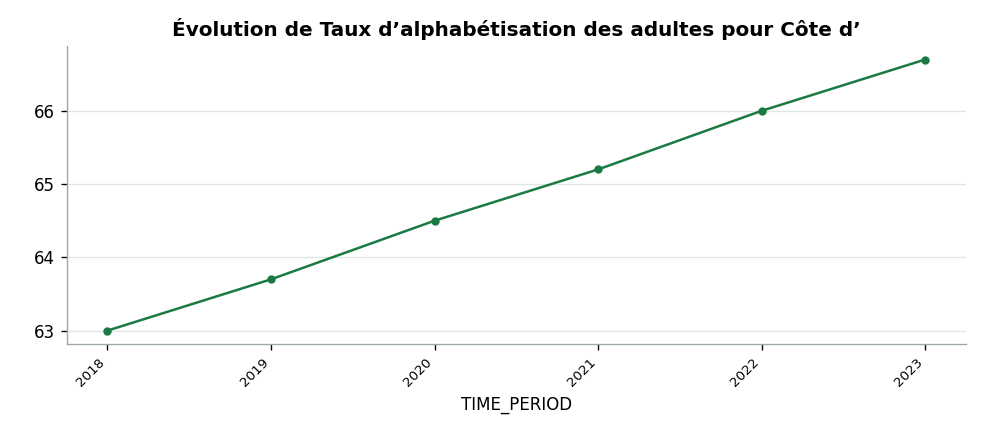

In [15]:
# ── Étape 9 · Mise en forme des réponses ────────────────────────────────────
ICONES = {"lister_dataflux": "📚", "decrire_dataflux": "🧱", "chercher_code": "🔤",
          "recuperer_donnees": "📈", "analyser_jeu": "🧮", "tracer_graphique": "📊", "exporter_csv": "💾"}

def _pastille(source):
    return (f"<span style='display:inline-block;background:#E8F5EF;color:#0F5A31;border:1px solid #BFE3CE;"
            f"border-radius:12px;padding:0 8px;margin:0 2px;font-size:11.5px'>{ICONES.get(source, '📄')} {source}</span>")

def texte_vers_html(texte):
    lignes, puces = [], []
    def vider():
        if puces:
            lignes.append("<ul style='margin:4px 0 4px 18px;padding:0'>" + "".join(f"<li>{p}</li>" for p in puces) + "</ul>")
            puces.clear()
    for brute in str(texte).strip().splitlines():
        ligne = html.escape(brute.strip())
        ligne = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", ligne)
        ligne = re.sub(r"`([^`]+)`", r"<code style='background:#EEF2F0;padding:1px 5px;border-radius:4px'>\1</code>", ligne)
        ligne = re.sub(r"\[([A-Za-z0-9_,.\- ]{3,90})\]", lambda m: "".join(_pastille(s.strip()) for s in m.group(1).split(",")), ligne)
        if re.match(r"^[-*•]\s+", brute.strip()):
            puces.append(re.sub(r"^[-*•]\s+", "", ligne)); continue
        vider()
        lignes.append(ligne or "<div style='height:6px'></div>")
    vider()
    sortie = ""
    for i, l in enumerate(lignes):
        bloc = l.startswith("<ul")
        sortie += ("" if i == 0 or bloc or lignes[i - 1].startswith("<ul") else "<br>") + l
    return sortie

def bulle_utilisateur(question):
    return (f"<div style='display:flex;justify-content:flex-end;margin:10px 0'>"
            f"<div style='max-width:78%;background:#0B2545;color:#fff;padding:10px 14px;border-radius:14px 14px 2px 14px;"
            f"{POLICE};font-size:14px'>🧑‍💼 {html.escape(question)}</div></div>")

def plan_vers_html(execution):
    if not execution.plan:
        return "<i>aucun plan</i>"
    faits = {e.numero: e for e in execution.etapes}
    lignes = []
    for etape in execution.plan:
        fait = faits.get(etape["numero"])
        statut = "⏳" if fait is None else ("✅" if fait.resultat and not fait.erreur else
                                            ("🕒" if fait.motif.startswith("mise en file") else "⚠️"))
        lignes.append(f"<li style='margin:2px 0'>{statut} <b>{html.escape(etape['outil'])}</b> — "
                      f"{html.escape(etape['but'])} <code style='font-size:11px'>"
                      f"{html.escape(json.dumps(etape['args'], ensure_ascii=False)[:70])}</code></li>")
    supplement = ("" if execution.corrections == 0 else
                  f"<div style='color:{OR};font-size:12px;margin-top:4px'>↻ {execution.corrections} correction(s) en cours d’exécution</div>")
    return f"<ol style='margin:4px 0 0 18px;padding:0;{POLICE};font-size:12.5px'>{''.join(lignes)}</ol>{supplement}"

def figure_vers_html(execution, magasin=MAGASIN):
    for jeu in reversed(execution.jeux):
        if jeu in magasin.figures:
            return (f"<img src='data:image/png;base64,{magasin.figures[jeu]}' "
                    f"style='width:100%;max-width:760px;border:1px solid #DDE3E0;border-radius:10px;margin-top:6px'/>")
    return ""

def donnees_vers_html(execution, magasin=MAGASIN, max_lignes=8):
    if not execution.jeux:
        return ""
    jeu = execution.jeux[-1]
    table = magasin.table(jeu)
    colonnes = [c for c in table.columns if not c.endswith("_LIBELLE")]
    return (f"<div style='{POLICE};font-size:12px;color:{GRIS};margin-top:6px'>{jeu} · {len(table)} ligne(s)</div>"
            + df_vers_html(table[colonnes], max_lignes))

def bulle_agent(execution, cerveau):
    couleur = VERT if execution.reponse and not execution.arret.startswith(("échec", "abandon")) else ROUGE
    meta = (f"Agent SDMX · {cerveau!r} · {len(execution.etapes)} étape(s) · {execution.appels_modele} appel(s) au modèle · "
            f"{execution.requetes_http} requête(s) HTTP · arrêt : {execution.arret}")
    details = (f"<div style='{POLICE};font-size:12.5px;margin-bottom:3px'><b>🗺️ Plan</b></div>{plan_vers_html(execution)}"
               f"<div style='{POLICE};font-size:12.5px;margin:8px 0 3px'><b>🧭 Trace d’exécution</b></div>"
               f"{df_vers_html(execution.journal(), 10)}")
    return (f"<div style='display:flex;justify-content:flex-start;margin:10px 0'>"
            f"<div style='max-width:92%;background:#fff;border:1px solid #DDE3E0;border-left:5px solid {couleur};"
            f"padding:10px 14px;border-radius:14px 14px 14px 2px;{POLICE};font-size:14px;line-height:1.6;"
            f"box-shadow:0 1px 3px rgba(0,0,0,.06)'>"
            f"<div>🤖 {texte_vers_html(execution.reponse)}</div>"
            f"{figure_vers_html(execution)}{donnees_vers_html(execution)}"
            f"<div style='margin-top:8px;color:{GRIS};font-size:11.5px'>{meta}</div>"
            f"<details style='margin-top:6px'><summary style='cursor:pointer;color:#12507A;font-size:12.5px'>"
            f"🗺️ Voir le plan et la trace</summary><div style='margin-top:6px'>{details}</div></details></div></div>")


def demander(question, cerveau=None, max_etapes=8, bavard=False):
    cerveau = cerveau or CERVEAU_LOCAL
    execution = AgentSDMX(OUTILS, cerveau, STRUCTURE, SERVICE, FILE, max_etapes=max_etapes).executer(question, bavard=bavard)
    display(HTML(bulle_utilisateur(question) + bulle_agent(execution, cerveau)))
    return execution

EXEMPLE = (f"Évolution de {STRUCTURE['dimensions'][-1]['codes'][0]['libelle']} "
           f"pour {STRUCTURE['dimensions'][1]['codes'][0]['libelle']} depuis 2018"
           if len(STRUCTURE["dimensions"]) > 2 and STRUCTURE["dimensions"][-1]["codes"] else "Donne-moi les dernières observations")
RUN_DEMO = demander(EXEMPLE, cerveau=CERVEAU_LLM or CERVEAU_LOCAL)

In [16]:
# ── Étape 9 (suite) · Auto-test de la chaîne ───────────────────────────────
questions_test = [EXEMPLE, "Quelles sont les dernières valeurs disponibles ?", "Compare les pays disponibles"]
lignes = []
for q in questions_test:
    ex = AgentSDMX(OUTILS, CERVEAU_LOCAL, STRUCTURE, SERVICE, FileApprobation(OUTILS_PAR_NOM)).executer(q)
    lignes.append({"question": q[:52], "étapes du plan": len(ex.plan), "étapes exécutées": len(ex.etapes),
                   "jeux produits": len(ex.jeux), "requêtes HTTP": ex.requetes_http,
                   "réponse": "✅" if ex.reponse else "❌", "arrêt": ex.arret})
tableau(pd.DataFrame(lignes), "La chaîne complète est exercée : planification, appels SDMX, calcul, rendu.")
# Démonstration : croiser DEUX dataflows différents sur le pays et l’année
try:
    pays = next((c["code"] for d in STRUCTURE["dimensions"] if d["id"].upper().startswith("REF") for c in d["codes"]), None)
    flux_a, flux_b = list(CATALOGUE.flux["flux"])[:2]
    ind_a = CATALOGUE.index[(CATALOGUE.index["flux"] == flux_a) & (CATALOGUE.index["dimension"] == "INDICATOR")]
    ind_b = CATALOGUE.index[(CATALOGUE.index["flux"] == flux_b) & (CATALOGUE.index["dimension"] == "INDICATOR")]
    if pays and not ind_a.empty and not ind_b.empty:
        outil = OUTILS_PAR_NOM["recuperer_donnees"]
        ja = outil.executer(flux=flux_a, cle=f".{pays}.{ind_a.iloc[0]['code']}", dernieres=8).split(" ")[0]
        jb = outil.executer(flux=flux_b, cle=f".{pays}.{ind_b.iloc[0]['code']}", dernieres=8).split(" ")[0]
        resultat = OUTILS_PAR_NOM["joindre_jeux"].executer(jeu_a=ja, jeu_b=jb)
        encadre(f"<code>{flux_a}</code> × <code>{flux_b}</code> croisés sur REF_AREA et TIME_PERIOD :<br>"
                f"<pre style='font-size:11.5px;margin:4px 0'>{html.escape(resultat[:450])}</pre>",
                "Croisement de deux jeux de données", "succes")
except Exception as e:
    encadre(f"Croisement non démontré ici ({type(e).__name__} : {e}).", "Croisement", "attention")

tableau(pd.DataFrame(CLIENT.journal_http[-8:]), "Dernières requêtes HTTP réellement envoyées au service "
        f"({CLIENT.requetes} requête(s), {CLIENT.depuis_cache} réponse(s) servie(s) par le cache).")

question,étapes du plan,étapes exécutées,jeux produits,requêtes HTTP,réponse,arrêt
Évolution de Taux d’alphabétisation des adultes pour,4,4,2,1,✅,plan terminé
Quelles sont les dernières valeurs disponibles ?,4,1,0,0,✅,abandon : le planificateur local n’a pas d’alternative à proposer
Compare les pays disponibles,5,1,0,0,✅,abandon : le planificateur local n’a pas d’alternative à proposer


url,statut,ms
[démo] dataflow/DEMO/DF_MACRO_DEMO/latest,démo,0
[démo] dataflow/DEMO/DF_POP_DEMO/latest,démo,0
[démo] dataflow/DEMO/DF_SANTE_DEMO/latest,démo,0
[démo] dataflow/DEMO/DF_TRADE_DEMO/latest,démo,0
"[démo] data/DEMO,DF_EDU_DEMO,latest/.CIV.LITERACY",démo,0
"[démo] data/DEMO,DF_EDU_DEMO,latest/.CIV.LITERACY",démo,0
"[démo] data/DEMO,DF_EDU_DEMO,latest/.CIV.LITERACY",démo,0
"[démo] data/DEMO,DF_MACRO_DEMO,latest/.CIV.GDP_GROWTH",démo,0


---
# 🟥 PARTIE 5 — L’interface en langage naturel

## Étape 10 · Poser une question, obtenir un tableau et un graphique

**🎯 Objectif :** mettre l’agent SDMX entre les mains d’un utilisateur qui ne connaît ni SDMX, ni les codes pays.

| Zone | Rôle |
|:--|:--|
| **⚙️ Réglages** | cerveau (planificateur local ou modèle), dataflow de travail, budget d’étapes |
| **💡 Suggestions** | questions types, construites à partir des **codes réellement disponibles** |
| **💬 Conversation** | la réponse, le graphique, le tableau, et le plan repliable |
| **🗺️ Plan** | le plan de la dernière question, étape par étape |
| **🌐 Requêtes** | les URL SDMX exactes, pour reproduire la réponse à la main |
| **✅ Approbations** | les exports CSV en attente de validation |
| **🧾 Journal** | les journaux d’audit chaînés et leur intégrité |

### 🔬 Expériences à faire

1. Posez une question **avec un pays et une période** ; ouvrez ensuite l’onglet **🌐 Requêtes** et collez l’URL dans votre navigateur : vous devez retrouver exactement les mêmes chiffres.
2. Demandez un **export CSV**, puis allez l’approuver dans **✅ Approbations**.
3. Changez de **dataflow** dans les réglages : les outils, les suggestions et les codes changent automatiquement.
4. Avec une clé Groq, comparez le **plan** produit par le modèle et celui du planificateur local.

In [ ]:
# ── Étape 10 · L’interface ──────────────────────────────────────────────────
import ipywidgets as widgets

CERVEAUX = [("🧪 Planificateur local (sans clé)", "local"), ("⚡ Groq — gratuit", "groq"),
            ("🔷 Gemini — gratuit", "gemini"), ("🖥️ Ollama — local", "ollama")]


def suggestions_depuis_catalogue(catalogue, structure, n=5):
    """Construit des questions types à partir de PLUSIEURS dataflows indexés."""
    propositions = []
    index = catalogue.index
    if not index.empty:
        zones = index[index["dimension"].str.upper().str.startswith(("REF_AREA", "AREA", "COUNTRY", "GEO"))]
        pays = list(zones["libelle"].unique())[:3]
        # on écarte les dimensions non informatives : fréquence, temps, unité…
        inutiles = index["dimension"].str.upper().str.startswith(("FREQ", "TIME", "UNIT", "OBS", "DECIMAL"))
        autres = index[~index.index.isin(zones.index) & ~inutiles]
        for flux, groupe in list(autres.groupby("flux"))[:4]:
            libelles = [l for l in groupe["libelle"].unique() if len(l) > 4][:1]
            if libelles and pays:
                propositions.append(f"Évolution de {libelles[0]} pour {pays[0]} depuis 2018")
        if len(pays) > 1 and not autres.empty:
            indic = next((l for l in autres["libelle"].unique() if len(l) > 4), None)
            if indic:
                propositions.append(f"Compare {indic} entre {pays[0]} et {pays[1]}")
    propositions += ["Quels jeux de données contiennent des données de population ?",
                     "Quelles sont les dernières valeurs disponibles ?"]
    return propositions[:n]


class InterfaceSDMX:
    def __init__(self, client, structure, service, file):
        self.client, self.structure, self.service, self.file = client, structure, service, file
        self.catalogue = CATALOGUE
        self.outils = OUTILS
        self.cerveaux = {"local": CERVEAU_LOCAL}
        if CERVEAU_LLM is not None:                      # cerveau préparé et testé à l’étape 8
            self.cerveaux[CERVEAU_LLM.fournisseur] = CERVEAU_LLM
        self.fil, self.executions, self.journaux = [], [], []
        self.dossier = SORTIES / "interface"
        self.dossier.mkdir(parents=True, exist_ok=True)
        self._construire()
        self._accueil()

    # ── construction ───────────────────────────────────────────────────────
    def _construire(self):
        L = widgets.Layout
        entete = widgets.HTML(
            f"<div style='background:linear-gradient(135deg,#0B2545 0%,#12507A 50%,#1B7A43 100%);border-radius:14px;"
            f"padding:14px 20px;{POLICE}'><div style='color:#F2A900;font-size:11px;letter-spacing:2.5px;font-weight:700'>"
            f"SERVICE SDMX · {self.service['nom'].upper()}</div>"
            f"<div style='color:#fff;font-size:21px;font-weight:800;margin-top:3px'>📊 Agent SDMX</div>"
            f"<div style='color:#d6e4ef;font-size:13px'>Posez votre question en français. L’agent planifie, "
            f"interroge le service, calcule, puis affiche le tableau et le graphique.</div></div>")

        style = {"description_width": "80px"}
        defaut = CERVEAU_LLM.fournisseur if CERVEAU_LLM is not None else "local"
        self.w_cerveau = widgets.Dropdown(options=CERVEAUX, value=defaut, description="🧠 Cerveau",
                                          style=style, layout=L(width="320px"))
        flux_options = [("🔎 automatique — l’agent choisit dans tout le catalogue", ("auto", "auto"))] + \
                       [(f"{r.flux} — {r.nom[:40]}", (r.agence, r.flux)) for r in self.catalogue.flux.itertuples()]
        self.w_flux = widgets.Dropdown(options=flux_options, value=("auto", "auto"),
                                       description="📚 Dataflow", style=style, layout=L(width="430px"))
        self.w_flux.observe(self._changer_flux, names="value")
        self.w_budget = widgets.IntSlider(value=8, min=3, max=12, description="⏱️ Budget", style=style, layout=L(width="300px"))
        reglages = widgets.VBox([widgets.HBox([self.w_cerveau, self.w_budget]), self.w_flux])

        self.w_suggestions = widgets.HBox(layout=L(flex_flow="row wrap"))
        self._remplir_suggestions()

        self.w_conv = widgets.HTML(layout=L(width="100%"))
        self.w_question = widgets.Text(placeholder="Ex. : évolution de l’inflation au Sénégal depuis 2018…", layout=L(width="70%"))
        self.w_envoyer = widgets.Button(description="Envoyer", icon="paper-plane", button_style="success", layout=L(width="130px"))
        self.w_effacer = widgets.Button(description="Effacer", icon="trash", layout=L(width="110px"))
        self.w_envoyer.on_click(self._envoyer)
        self.w_effacer.on_click(self._effacer)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                self.w_question.on_submit(self._envoyer)
            except Exception:
                pass
        self.w_statut = widgets.HTML()

        self.w_plan = widgets.HTML()
        self.w_requetes = widgets.HTML()
        self.w_approbations = widgets.VBox()
        self.w_journal = widgets.HTML()
        self.w_catalogue = widgets.HTML()
        self.w_recherche = widgets.Text(placeholder="Chercher un indicateur ou un jeu de données…", layout=L(width="60%"))
        self.w_chercher = widgets.Button(description="Chercher", icon="search", layout=L(width="120px"))
        self.w_chercher.on_click(self._chercher_catalogue)
        onglet_catalogue = widgets.VBox([widgets.HBox([self.w_recherche, self.w_chercher]), self.w_catalogue])
        self.onglets = widgets.Tab(children=[self.w_plan, onglet_catalogue, self.w_requetes,
                                             self.w_approbations, self.w_journal])
        for i, titre in enumerate(["🗺️ Plan", "📚 Catalogue", "🌐 Requêtes", "✅ Approbations", "🧾 Journal"]):
            self.onglets.set_title(i, titre)

        def titre(t):
            return widgets.HTML(f"<div style='{POLICE};font-weight:700;color:#0B2545;margin:10px 0 2px'>{t}</div>")

        self.app = widgets.VBox([entete, titre("⚙️ Réglages"), reglages, titre("💡 Suggestions"), self.w_suggestions,
                                 titre("💬 Conversation"), self.w_conv,
                                 widgets.HBox([self.w_question, self.w_envoyer, self.w_effacer]), self.w_statut,
                                 titre("🔬 Traçabilité"), self.onglets], layout=L(width="100%", max_width="1020px"))

    def _remplir_suggestions(self):
        boutons = []
        for s in suggestions_depuis_catalogue(self.catalogue, self.structure):
            b = widgets.Button(description=s if len(s) <= 48 else s[:46] + "…", tooltip=s,
                               layout=widgets.Layout(width="auto", margin="2px"))
            b.on_click(lambda _, q=s: setattr(self.w_question, "value", q))
            boutons.append(b)
        self.w_suggestions.children = boutons

    # ── affichage ──────────────────────────────────────────────────────────
    def _accueil(self):
        dims = ", ".join(d["id"] for d in self.structure["dimensions"])
        self.fil = [f"<div style='{POLICE};background:#fff;border:1px solid #DDE3E0;border-left:5px solid {VERT};"
                    f"border-radius:14px;padding:10px 14px;font-size:14px'>🤖 Bonjour ! J’interroge le service "
                    f"<b>{html.escape(self.service['nom'])}</b>, qui publie "
                    f"<b>{len(self.catalogue.flux)}</b> jeu(x) de données.<br>"
                    f"En mode <b>🔎 automatique</b>, je choisis moi-même le dataflux adapté à votre question ; "
                    f"vous pouvez aussi en imposer un dans les réglages.<br>"
                    f"Dataflow de départ : <code>{self.structure['flux']}</code> — dimensions <code>{dims}</code>.<br>"
                    f"Posez votre question, ou choisissez une suggestion.</div>"]
        self._rafraichir()

    def _rafraichir(self):
        self.w_conv.value = (f"<div style='background:#F7FAF8;border:1px solid #DDE3E0;border-radius:12px;padding:6px 12px;"
                             f"height:470px;overflow-y:auto;{POLICE}'>" + "".join(self.fil) + "</div>")
        self._rafraichir_requetes(); self._rafraichir_approbations(); self._rafraichir_journal()
        self._rafraichir_catalogue()

    def _statut(self, texte, couleur=GRIS):
        self.w_statut.value = f"<div style='{POLICE};font-size:12.5px;color:{couleur};margin:4px 2px'>{texte}</div>"

    def _rafraichir_catalogue(self, resultats=None):
        index = self.catalogue.index
        entete = (f"<div style='{POLICE};font-size:12.5px;margin:4px 0'><b>{len(self.catalogue.flux)}</b> jeu(x) de données publiés · "
                  f"<b>{index['flux'].nunique() if not index.empty else 0}</b> indexé(s) · "
                  f"<b>{len(index)}</b> code(s) dans l’annuaire</div>")
        if resultats is not None:
            corps = df_vers_html(resultats, 15) if not resultats.empty else "<i>aucun résultat</i>"
        else:
            corps = df_vers_html(self.catalogue.flux, 12)
        self.w_catalogue.value = entete + corps

    def _chercher_catalogue(self, _=None):
        texte = self.w_recherche.value.strip()
        if not texte:
            self._rafraichir_catalogue()
            return
        flux = self.catalogue.chercher_flux(texte, k=8)
        codes = self.catalogue.chercher_code(texte)
        bloc = f"<div style='{POLICE};font-size:12.5px;margin:6px 0'><b>Jeux de données</b></div>"
        bloc += df_vers_html(flux[["flux", "nom", "score"]], 8) if not flux.empty else "<i>aucun</i>"
        bloc += f"<div style='{POLICE};font-size:12.5px;margin:8px 0 4px'><b>Codes correspondants</b></div>"
        bloc += df_vers_html(codes[["flux", "dimension", "code", "libelle"]], 12) if not codes.empty else "<i>aucun</i>"
        self.w_catalogue.value = bloc

    def _rafraichir_requetes(self):
        journal = self.client.journal_http[-15:]
        if not journal:
            self.w_requetes.value = f"<div style='{POLICE};font-size:13px;color:{GRIS}'>Aucune requête pour l’instant.</div>"
            return
        lignes = "".join(f"<li style='margin:3px 0;word-break:break-all'><code style='font-size:11.5px'>"
                         f"{html.escape(str(r['url']))}</code> <span style='color:{GRIS}'>· {r['statut']} · {r['ms']} ms</span></li>"
                         for r in journal)
        self.w_requetes.value = (f"<div style='{POLICE};font-size:12.5px'>Ces URL sont reproductibles telles quelles "
                                 f"dans un navigateur ou avec <code>curl</code> :<ul>{lignes}</ul></div>")

    def _rafraichir_approbations(self):
        attente = self.file.en_attente()
        blocs = [widgets.HTML(f"<div style='{POLICE};font-size:13px'><b>{len(attente)}</b> demande(s) en attente · "
                              f"{len(self.file.decisions)} décision(s)</div>")]
        for d in attente:
            carte = widgets.HTML(f"<div style='{POLICE};border:1px solid {OR};background:#FFFBEF;border-radius:10px;"
                                 f"padding:8px 12px;font-size:12.5px'><b>Demande n°{d.numero}</b> · <code>{d.outil}</code>"
                                 f"<br>{html.escape(json.dumps(d.args, ensure_ascii=False))}"
                                 f"<br><span style='color:{GRIS}'>Question : {html.escape(d.tache[:70])}</span></div>",
                                 layout=widgets.Layout(width="70%"))
            ok = widgets.Button(description="Approuver", icon="check", button_style="success", layout=widgets.Layout(width="120px"))
            ko = widgets.Button(description="Rejeter", icon="times", button_style="danger", layout=widgets.Layout(width="110px"))
            ok.on_click(lambda _, n=d.numero: self._decider(n, True))
            ko.on_click(lambda _, n=d.numero: self._decider(n, False))
            blocs.append(widgets.HBox([carte, widgets.VBox([ok, ko])]))
        if self.file.decisions:
            histo = pd.DataFrame([{"n°": e["numero"], "outil": e["outil"], "décision": e["statut"],
                                   "par": e["decideur"], "empreinte": e["hash"][:12] + "…"} for e in self.file.decisions])
            blocs.append(widgets.HTML(df_vers_html(histo)))
        self.w_approbations.children = blocs

    def _rafraichir_journal(self):
        if not self.journaux:
            self.w_journal.value = f"<div style='{POLICE};font-size:13px;color:{GRIS}'>Aucun journal enregistré.</div>"
            return
        lignes = []
        for chemin, question in self.journaux[-10:]:
            ok, etat = verifier_journal(chemin)
            lignes.append({"fichier": chemin.name, "question": question[:50], "intégrité": f"{'🔒' if ok else '🚩'} {etat}"})
        self.w_journal.value = (f"<div style='{POLICE};font-size:12.5px'>Dossier : <code>{self.dossier}</code></div>"
                                + df_vers_html(pd.DataFrame(lignes)))

    # ── actions ────────────────────────────────────────────────────────────
    def _changer_flux(self, evenement):
        agence, flux = evenement["new"]
        if flux == "auto":
            self.fil.append(f"<div style='{POLICE};text-align:center;color:#5c4500;background:#FFF7E0;border:1px dashed {OR};"
                            f"border-radius:10px;padding:6px 12px;margin:8px auto;font-size:12.5px'>"
                            f"🔎 Mode automatique : l’agent choisira lui-même parmi les "
                            f"<b>{len(self.catalogue.flux)}</b> jeux de données du catalogue.</div>")
            self._statut("🔎 Choix automatique du dataflow activé", VERT)
            self._rafraichir()
            return
        self._statut("⏳ Découverte de la structure…", MARINE)
        try:
            self.structure = self.catalogue.structure(flux, agence)
            self.outils = construire_outils(self.catalogue, flux)
            self.file = FileApprobation({o.nom: o for o in self.outils})
            self.cerveaux["local"] = PlanificateurLocal(self.catalogue, flux)
            self._remplir_suggestions()
            self.fil.append(f"<div style='{POLICE};text-align:center;color:#5c4500;background:#FFF7E0;border:1px dashed {OR};"
                            f"border-radius:10px;padding:6px 12px;margin:8px auto;font-size:12.5px'>"
                            f"🔄 Dataflow changé : <b>{html.escape(self.structure['nom'])}</b> — "
                            f"outils et suggestions régénérés</div>")
            self._statut(f"✅ {self.structure['nom']}", VERT)
        except Exception as e:
            self._statut(f"⚠️ {type(e).__name__} : {e}", ROUGE)
        self._rafraichir()

    def _cerveau(self):
        cle = self.w_cerveau.value
        if cle not in self.cerveaux:
            self.cerveaux[cle] = ModeleCompatibleOpenAI(cle, MODELE)      # le MODELE de l’étape 8 est respecté
        return self.cerveaux[cle]

    def _envoyer(self, _=None):
        question = self.w_question.value.strip()
        if not question:
            self._statut("✍️ Écrivez d’abord une question.", OR)
            return
        self.w_question.value = ""
        self.w_envoyer.disabled = True
        self.fil.append(bulle_utilisateur(question))
        self._rafraichir()
        self._statut("⏳ Planification et interrogation du service…", MARINE)
        try:
            cerveau = self._cerveau()
            execution = AgentSDMX(self.outils, cerveau, self.structure, self.service, self.file,
                                  max_etapes=self.w_budget.value).executer(question)
            self.executions.append(execution)
            self.fil.append(bulle_agent(execution, cerveau))
            self.w_plan.value = plan_vers_html(execution) + df_vers_html(execution.journal(), 12)
            chemin = self.dossier / f"journal_{len(self.journaux) + 1:03d}.json"
            sauvegarder_journal(execution, chemin, {"cerveau": repr(cerveau), "flux": self.structure["flux"]})
            self.journaux.append((chemin, question))
            if self.file.en_attente():
                self.fil.append(f"<div style='{POLICE};text-align:center;background:#FFF7E0;border:1px dashed {OR};"
                                f"border-radius:10px;padding:6px 12px;margin:8px auto;font-size:12.5px;color:#5c4500'>"
                                f"🕒 Un export attend votre décision dans l’onglet <b>✅ Approbations</b>.</div>")
                self.onglets.selected_index = 2
            self._statut(f"✅ {len(execution.etapes)} étape(s) · {execution.requetes_http} requête(s) HTTP", VERT)
        except Exception as e:
            self.fil.append(f"<div style='{POLICE};background:#FBECEA;border-left:5px solid {ROUGE};border-radius:10px;"
                            f"padding:10px 14px;margin:8px 0;font-size:13.5px'>🤖 Je n’ai pas pu traiter la demande : "
                            f"<b>{type(e).__name__}</b> — {html.escape(str(e))}</div>")
            self._statut(f"⚠️ {type(e).__name__}", ROUGE)
        finally:
            self.w_envoyer.disabled = False
            self._rafraichir()

    def _decider(self, numero, approuver):
        demande = self.file.decider(numero, approuver)
        message = (f"✅ Demande n°{numero} approuvée — {html.escape(demande.resultat)}" if approuver
                   else f"⛔ Demande n°{numero} rejetée — aucun fichier écrit.")
        self.fil.append(f"<div style='{POLICE};text-align:center;background:#F4F7F5;border:1px dashed "
                        f"{VERT if approuver else ROUGE};border-radius:10px;padding:6px 12px;margin:8px auto;"
                        f"font-size:12.5px'>{message}</div>")
        self._rafraichir()

    def _effacer(self, _=None):
        self.executions.clear(); MAGASIN.vider(); self._accueil()
        self._statut("🧹 Conversation effacée (les journaux sont conservés).")

    def afficher(self):
        display(self.app)


APP = InterfaceSDMX(CLIENT, STRUCTURE, SERVICE, FILE)
APP.afficher()

## Étape 11 · Sous le capot

**🎯 Objectif :** savoir expliquer, sans le notebook sous les yeux, le trajet d’une question.

| # | Où | Ce qui se passe |
|:--:|:--|:--|
| 1 | Interface | la question et les réglages (cerveau, dataflow, budget) sont lus |
| 2 | Planificateur | un appel au modèle produit un **plan** de 1 à 6 étapes, en JSON |
| 3 | Substitution | `{{jeu}}` et `{{code}}` sont remplacés par les résultats des étapes précédentes |
| 4 | Politique | requête trop large → refusée ; export CSV → mis en **file d’approbation** |
| 5 | Client SDMX | l’URL est construite, mise en cache, et **journalisée telle quelle** |
| 6 | Magasin | le tableau est rangé sous un identifiant ; seul un **résumé** remonte au modèle |
| 7 | Correction | en cas d’échec, l’erreur repart vers le modèle, qui propose une étape de remplacement |
| 8 | Synthèse | un dernier appel rédige la réponse **à partir des seuls résultats d’outils** |
| 9 | Journal | plan, étapes, URL et réponse sont enregistrés et chaînés par empreintes SHA-256 |

**🧠 Ce qui distingue cet agent du précédent laboratoire :** il ne lit pas des documents, il **interroge un service vivant**. Deux conséquences : ses réponses changent quand les données changent (d’où l’importance de journaliser l’URL et l’horodatage), et il peut **mettre en difficulté un service de production** s’il n’est pas bridé (d’où les budgets de requêtes et la limite d’observations).

---
# ⬛ PARTIE 6 — Conclure

## Étape 12 · Limites, exercices et dépannage

### ⚠️ Limites de ce que vous avez construit

- **Le planificateur local n’est pas un modèle de langage.** Il fait correspondre des libellés à des codes ; il échoue sur les formulations inattendues. C’est voulu : il rend l’atelier utilisable sans clé.
- **Le croisement reste simple.** `joindre_jeux` aligne deux extractions sur le pays et l’année ; des dimensions hétérogènes (unités, fréquences différentes) demandent encore un travail manuel.
- **L’indexation est plafonnée** par `MAX_FLUX_INDEXES` : sur un service qui publie des centaines de dataflows, les jeux non indexés ne sont trouvés que si l’agent les cherche explicitement (passez `INDEXER_TOUT = True` pour tout indexer, au prix d’une requête par dataflow).
- **Pas de gestion fine des attributs SDMX** (statut d’observation, unité, multiplicateur). En production, ces attributs doivent être lus, car ils changent l’interprétation d’un chiffre.
- **Le cache ne se périme pas.** Pratique en atelier, dangereux en production : ajoutez une durée de vie, ou utilisez `updatedAfter`.
- **Aucune authentification.** Certaines instances exigent un jeton ; le client devrait alors gérer un en-tête `Authorization`.

### ✅ Point de contrôle

| Question | Réponse |
|:--|:--|
| Pourquoi l’agent appelle-t-il `chercher_code` avant `recuperer_donnees` ? | Pour ne jamais inventer un code : les codes viennent des codelists du service |
| Pourquoi le tableau de données ne remonte-t-il pas au modèle ? | Coût et contexte : le modèle reçoit un résumé, les données restent dans le magasin |
| Que garantit la journalisation de l’URL ? | La **reproductibilité** : un tiers peut rejouer la requête et vérifier le chiffre |
| Quels garde-fous protègent le service ? | Limite d’observations, refus de la clé `all` sans période, budget de requêtes, cache |
| Que se passe-t-il si une étape échoue ? | L’erreur repart vers le modèle qui propose une correction, dans la limite de 3 |

### 🧑‍💻 À vous de jouer

1. **Attributs.** Ajoutez la lecture de `OBS_STATUS` et de `UNIT_MEASURE`, et affichez l’unité dans le graphique.
2. **Deux dataflows.** Écrivez un outil `joindre_jeux(jeu_a, jeu_b, sur)` qui aligne deux extractions sur le pays et l’année.
3. **Fraîcheur.** Ajoutez un paramètre `updatedAfter` et un bouton « Vérifier les mises à jour ».
4. **Validation du plan.** Faites approuver le **plan** par l’utilisateur avant exécution, pour les requêtes coûteuses.
5. **Export enrichi.** Produisez un classeur Excel avec les données, les métadonnées et l’URL de la requête.

### 🛟 Dépannage

| Symptôme | Solution |
|:--|:--|
| « service injoignable » sur l’endpoint BAD | Le service NSI est probablement réservé au réseau interne : exécutez le notebook depuis le réseau de la BAD, ou restez sur le service de secours |
| 404 sur une requête de données | La clé ne respecte pas l’ordre des dimensions : relisez `decrire_dataflux` |
| 413 ou requête interminable | Restreignez la clé et la période ; utilisez `dernieres` |
| Le graphique est vide | Le jeu ne contient pas de dimension temporelle, ou toutes les valeurs sont manquantes |
| Réponses figées après modification côté service | Videz le cache : supprimez le dossier `stg17_sdmx/cache` |
| L’interface ne s’affiche pas | Réexécutez la cellule de l’étape 10, ou utilisez `demander("…")` |

---

*Atelier STG17 · BAD / STATAFRIC · « Agent SDMX » · Le notebook n’écrit rien sans approbation humaine et journalise chaque requête.*